# Razorpay AI Revenue Recovery — v5 Dataset Pipeline

Runs the full data pipeline end to end:

1. **Fix v5 issues** — exercise triage properly, make channel effectiveness context-dependent, separate the synthetic counterfactual benchmark from observed outcomes
2. **Generate raw diagnostic text** — messy gateway/bank messages for the root-cause classifier to actually learn from
3. **Train the root-cause classifier** — XGBoost + TF-IDF + SHAP, with a confidence gate, replacing the leaky `predicted_failure` column
4. **Audit** — structural integrity, referential integrity, leakage audit, statistical sanity checks

**Before running:** upload your 5 raw CSVs (`customers.csv`, `payment_attempts.csv`, `recovery_actions.csv`, `recovery_events.csv`, `model_feedback.csv`) into the `WORKDIR` folder set up below — either via the Colab file browser (left sidebar → folder icon → upload) or by mounting Drive.

Runtime: **CPU is enough**, no GPU needed. Full run takes ~2 minutes (SHAP over 100k rows is the slow part, ~60-90s).

In [1]:
!pip install shap -q

## Setup — set your working directory

Option A (default): files live directly in the Colab session at `/content/data` — upload them there via the file browser. **This is wiped when the runtime disconnects.**

Option B (recommended if you're working across multiple sessions): mount Drive and point `WORKDIR` at a folder there. Uncomment the two lines below.

In [2]:
import os


# Option B (recommended if you're working across multiple sessions): persist to Drive instead
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
WORKDIR = "/content/drive/MyDrive/data"

# Ensure the directory exists
os.makedirs(WORKDIR, exist_ok=True)
print(f"Working directory set to: {WORKDIR}")

Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/data


## Check the raw files are present

If this fails, upload the 5 CSVs into `WORKDIR` first (Colab file browser → right-click the folder → Upload, or drag-and-drop).

In [3]:
REQUIRED = ["customers.csv", "payment_attempts.csv", "recovery_actions.csv",
            "recovery_events.csv", "model_feedback.csv"]
missing = [f for f in REQUIRED if not os.path.exists(f"{WORKDIR}/{f}")]
if missing:
    raise FileNotFoundError(
        f"Missing from {WORKDIR}: {missing}\n"
        f"Upload these 5 raw CSVs into that folder, then re-run this cell."
    )
print("All 5 raw files found.")

All 5 raw files found.


---
## Step 1 — Fix the v5 issues

- **Triage now actually decides things**: probability floor (0.45) + expected-value threshold (₹80 buffer) gate the best-ranked channel, targeting ~85-95% PURSUED with both floor and EV rejections represented.
- **Channel effectiveness is context-dependent**: `true_success_probability` is built from error_code × channel × device × network × tier × time-since-failure interactions, so the *ranking* of channels flips across contexts instead of one channel dominating everywhere.
- **Counterfactual vs. observed, clearly separated**: `recovery_actions.csv` (5 rows/transaction) is the synthetic counterfactual benchmark; `recovery_events.csv` (1 row/transaction) is what production would actually observe. `payment_attempts.csv` and `customers.csv` pass through unchanged.

In [4]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(7)

IN = WORKDIR
OUT = WORKDIR

pa = pd.read_csv(f"{IN}/payment_attempts.csv")
cu = pd.read_csv(f"{IN}/customers.csv")

CHANNELS = ["WhatsApp", "SMS", "Email", "Retry", "Alternate Method"]
ACTION_COST = {"WhatsApp": 0.50, "SMS": 0.15, "Email": 0.05, "Retry": 0.00, "Alternate Method": 0.20}

# --- 1. Build long format: one row per (transaction, channel) = 100,000 x 5 ---
base = pa.merge(cu, on="customer_id", how="left")
long = base.loc[base.index.repeat(len(CHANNELS))].reset_index(drop=True)
long["communication_channel"] = np.tile(CHANNELS, len(base))
long["action_id"] = [f"ACT_{i+1:08d}" for i in range(len(long))]
long["attempt_number"] = 1
long["action_cost"] = long["communication_channel"].map(ACTION_COST)
long["time_since_failure"] = rng.integers(60, 1800, size=len(long))  # minutes

# --- 2. Eligibility: retrying the same instrument doesn't make sense when the
#        failure is instrument-specific (insufficient funds / expired card). ---
RETRY_INELIGIBLE_ERRORS = {"ERR_INSUFFICIENT_FUNDS", "ERR_EXPIRED_CARD"}
long["eligible"] = ~(
    (long["communication_channel"] == "Retry") & (long["error_code"].isin(RETRY_INELIGIBLE_ERRORS))
)

# --- 3. Context-dependent TRUE success probability (ground truth) ---
BASE_RATE = {
    "ERR_INSUFFICIENT_FUNDS": 0.35, "ERR_BANK_TIMEOUT": 0.55, "ERR_USER_ABORT": 0.45,
    "ERR_EXPIRED_CARD": 0.25, "ERR_GATEWAY_TIMEOUT": 0.50,
}

# error_code x channel affinity -- this is where the crossover lives.
AFFINITY = {
    "ERR_INSUFFICIENT_FUNDS": {"WhatsApp": 0.90, "SMS": 0.95, "Email": 0.70, "Retry": 0.30, "Alternate Method": 1.30},
    "ERR_BANK_TIMEOUT":       {"WhatsApp": 1.00, "SMS": 0.95, "Email": 0.60, "Retry": 1.50, "Alternate Method": 1.10},
    "ERR_USER_ABORT":         {"WhatsApp": 1.30, "SMS": 1.05, "Email": 0.60, "Retry": 0.40, "Alternate Method": 1.00},
    "ERR_EXPIRED_CARD":       {"WhatsApp": 0.85, "SMS": 0.80, "Email": 1.00, "Retry": 0.15, "Alternate Method": 1.40},
    "ERR_GATEWAY_TIMEOUT":    {"WhatsApp": 1.00, "SMS": 0.90, "Email": 0.60, "Retry": 1.40, "Alternate Method": 1.05},
}

DEVICE_MOD = {
    "Android": {"WhatsApp": 1.05, "SMS": 1.10, "Email": 0.90, "Retry": 1.00, "Alternate Method": 1.00},
    "iOS":     {"WhatsApp": 1.15, "SMS": 0.95, "Email": 1.10, "Retry": 1.00, "Alternate Method": 1.00},
    "Web":     {"WhatsApp": 0.70, "SMS": 0.90, "Email": 1.10, "Retry": 1.00, "Alternate Method": 1.05},
}

NETWORK_MOD = {
    "4G":   {"WhatsApp": 1.10, "SMS": 1.00, "Email": 1.00, "Retry": 1.00, "Alternate Method": 1.00},
    "5G":   {"WhatsApp": 1.15, "SMS": 1.00, "Email": 1.00, "Retry": 1.00, "Alternate Method": 1.00},
    "Wifi": {"WhatsApp": 1.05, "SMS": 1.00, "Email": 1.05, "Retry": 1.00, "Alternate Method": 1.00},
}

TIER_MOD = {
    "High":   {"WhatsApp": 1.15, "SMS": 1.00, "Email": 1.10, "Retry": 1.00, "Alternate Method": 1.00},
    "Medium": {"WhatsApp": 1.00, "SMS": 1.00, "Email": 1.00, "Retry": 1.00, "Alternate Method": 1.00},
    "Low":    {"WhatsApp": 0.90, "SMS": 1.10, "Email": 0.95, "Retry": 1.00, "Alternate Method": 1.00},
}

QUICK = long["time_since_failure"] < 360  # first 6 hours

def map2d(d, keys, channels):
    out = np.ones(len(keys))
    for k in set(keys):
        sub = d.get(k, {})
        mask = (keys == k).values
        for ch, mult in sub.items():
            ch_mask = mask & (channels == ch).values
            out[ch_mask] = mult
    return out

base_rate = long["error_code"].map(BASE_RATE).values
affinity = map2d(AFFINITY, long["error_code"], long["communication_channel"])
device_mod = map2d(DEVICE_MOD, long["device_type"], long["communication_channel"])
network_mod = map2d(NETWORK_MOD, long["network_type"], long["communication_channel"])
tier_mod = map2d(TIER_MOD, long["customer_value_tier"], long["communication_channel"])

time_mod = np.ones(len(long))
transient = long["error_code"].isin(["ERR_BANK_TIMEOUT", "ERR_GATEWAY_TIMEOUT"]).values
balance_dep = long["error_code"].isin(["ERR_INSUFFICIENT_FUNDS"]).values
quick = QUICK.values
time_mod[transient & quick] = 1.25
time_mod[transient & ~quick] = 0.80
time_mod[balance_dep & quick] = 0.80
time_mod[balance_dep & ~quick] = 1.20

hist_mod = (0.7 + long["historical_success_rate"].values * 0.6)
noise = rng.normal(1.0, 0.06, size=len(long))

true_prob = base_rate * affinity * device_mod * network_mod * tier_mod * time_mod * hist_mod * noise
true_prob = np.clip(true_prob, 0.02, 0.95)
long["true_success_probability"] = true_prob.round(4)

pred_noise = rng.normal(0, 0.09, size=len(long))
long["predicted_success_probability"] = np.clip(true_prob + pred_noise, 0.02, 0.97).round(4)

# --- 4. Draw ONE outcome per (transaction, channel) ---
draw = rng.random(len(long))
long["actual_outcome"] = np.where(draw < long["true_success_probability"], "PAID", "NOT_PAID")
long["recovered_amount"] = np.where(long["actual_outcome"] == "PAID", long["amount"], 0.0).round(2)

# --- 5. Save recovery_actions.csv -- SYNTHETIC COUNTERFACTUAL BENCHMARK ---
recovery_actions = long[[
    "transaction_id", "action_id", "communication_channel", "payment_method",
    "attempt_number", "action_cost", "time_since_failure", "eligible",
    "true_success_probability", "predicted_success_probability",
    "actual_outcome", "recovered_amount",
]].copy()
recovery_actions["dataset_type"] = "synthetic_counterfactual_benchmark"
recovery_actions.to_csv(f"{OUT}/recovery_actions.csv", index=False)

print("Step 1a done: recovery_actions.csv written,", recovery_actions.shape)

Step 1a done: recovery_actions.csv written, (500000, 13)


In [5]:
# --- 6. Triage + channel ranking -> exactly ONE action per transaction (or none) ---
PROB_FLOOR = 0.45
EV_MIN = 80.0  # INR buffer over cost

long["predicted_ev"] = long["predicted_success_probability"] * long["amount"] - long["action_cost"]

elig = long[long["eligible"]].copy()
best_idx = elig.groupby("transaction_id")["predicted_ev"].idxmax()
best = elig.loc[best_idx].copy()

floor_fail = best["predicted_success_probability"] < PROB_FLOOR
ev_fail = best["predicted_ev"] < EV_MIN

decision = np.where(floor_fail | ev_fail, "NOT_PURSUED", "PURSUED")
reason = np.select(
    [floor_fail & ev_fail, floor_fail & ~ev_fail, ~floor_fail & ev_fail],
    ["probability_floor_failure+expected_value_failure", "probability_floor_failure", "expected_value_failure"],
    default="",
)
best["decision"] = decision
best["reasoning"] = reason

events_rows = []
for i, r in enumerate(best.itertuples(index=False)):
    txn = r.transaction_id
    pursued = r.decision == "PURSUED"
    events_rows.append({
        "attempt_id": f"ATT_{i+1:08d}",
        "transaction_id": txn,
        "attempt_number": 1,
        "communication_channel": r.communication_channel if pursued else None,
        "payment_method": r.payment_method,
        "predicted_probability": r.predicted_success_probability,
        "expected_value_inr": round(r.predicted_ev, 2),
        "probability_floor_pass": not floor_fail.iloc[i],
        "expected_value_pass": not ev_fail.iloc[i],
        "decision": r.decision,
        "reasoning": r.reasoning if not pursued else "probability_floor_and_expected_value_pass",
        "state": ("RECOVERED" if (pursued and r.actual_outcome == "PAID")
                  else "FAILED" if pursued else "NOT_PURSUED"),
        "timestamp": r.timestamp,
        "idempotency_key": f"{txn}_{r.communication_channel}_1" if pursued else f"{txn}_NONE_0",
        "actual_outcome": r.actual_outcome if pursued else "NOT_ATTEMPTED",
        "recovered_amount": r.recovered_amount if pursued else 0.0,
    })

recovery_events = pd.DataFrame(events_rows)
recovery_events["dataset_type"] = "observed_recovery_outcome"
recovery_events.to_csv(f"{OUT}/recovery_events.csv", index=False)

# --- 7. model_feedback.csv -- scored ONLY against observed outcomes ---
mf_orig = pd.read_csv(f"{IN}/model_feedback.csv")[["transaction_id", "model_version", "predicted_failure", "failure_probability"]]
mf = recovery_events.merge(mf_orig, on="transaction_id", how="left")

pursued_mask = mf["decision"] == "PURSUED"
outcome_numeric = np.where(mf["actual_outcome"] == "PAID", 1.0, 0.0)
mf["prediction_error"] = np.where(pursued_mask, (mf["predicted_probability"] - outcome_numeric).abs().round(4), np.nan)

model_feedback = mf.rename(columns={
    "communication_channel": "predicted_action",
    "predicted_probability": "predicted_success_probability",
}).copy()
model_feedback["actual_action"] = model_feedback["predicted_action"]
model_feedback = model_feedback[[
    "transaction_id", "model_version", "predicted_failure", "failure_probability",
    "predicted_action", "predicted_success_probability", "actual_action",
    "actual_outcome", "prediction_error", "timestamp",
]]
model_feedback.to_csv(f"{OUT}/model_feedback.csv", index=False)

# customers.csv / payment_attempts.csv carried through unchanged
pa.to_csv(f"{OUT}/payment_attempts.csv", index=False)
cu.to_csv(f"{OUT}/customers.csv", index=False)

print("Step 1b done: recovery_events.csv + model_feedback.csv written")
print("\nPURSUED / NOT_PURSUED split:")
print(recovery_events["decision"].value_counts(normalize=True).round(3))
print("\nNOT_PURSUED reasons:")
print(recovery_events.loc[recovery_events["decision"] == "NOT_PURSUED", "reasoning"].value_counts())

Step 1b done: recovery_events.csv + model_feedback.csv written

PURSUED / NOT_PURSUED split:
decision
PURSUED        0.9
NOT_PURSUED    0.1
Name: proportion, dtype: float64

NOT_PURSUED reasons:
reasoning
probability_floor_failure                           8444
expected_value_failure                              1083
probability_floor_failure+expected_value_failure     505
Name: count, dtype: int64


In [6]:
# Sanity check: channel effectiveness by error_code (should NOT be one channel dominating)
check = long[long["eligible"]].merge(pa[["transaction_id", "error_code"]], on="transaction_id", suffixes=("", "_dup"))
check.pivot_table(index="error_code", columns="communication_channel",
                   values="true_success_probability", aggfunc="mean").round(3)

communication_channel,Alternate Method,Email,Retry,SMS,WhatsApp
error_code,,,,,
ERR_BANK_TIMEOUT,0.628,0.349,0.808,0.566,0.684
ERR_EXPIRED_CARD,0.416,0.302,NaN,0.248,0.307
ERR_GATEWAY_TIMEOUT,0.536,0.314,0.713,0.490,0.626
ERR_INSUFFICIENT_FUNDS,0.610,0.334,NaN,0.465,0.516
ERR_USER_ABORT,0.534,0.326,0.213,0.585,0.831


Train: 356,424 | Test: 89,073 | Positive rate train/test: 0.504 / 0.503
ROC-AUC : 0.7140
PR-AUC  : 0.7231  (baseline = positive rate = 0.5028)
Brier   : 0.2145  (0 = perfectly calibrated)

Applied Optimal Threshold: 0.343 (Max F1=0.6932)
              precision    recall  f1-score   support

    NOT_PAID       0.72      0.37      0.49     44284
        PAID       0.58      0.86      0.69     44789

    accuracy                           0.62     89073
   macro avg       0.65      0.62      0.59     89073
weighted avg       0.65      0.62      0.59     89073



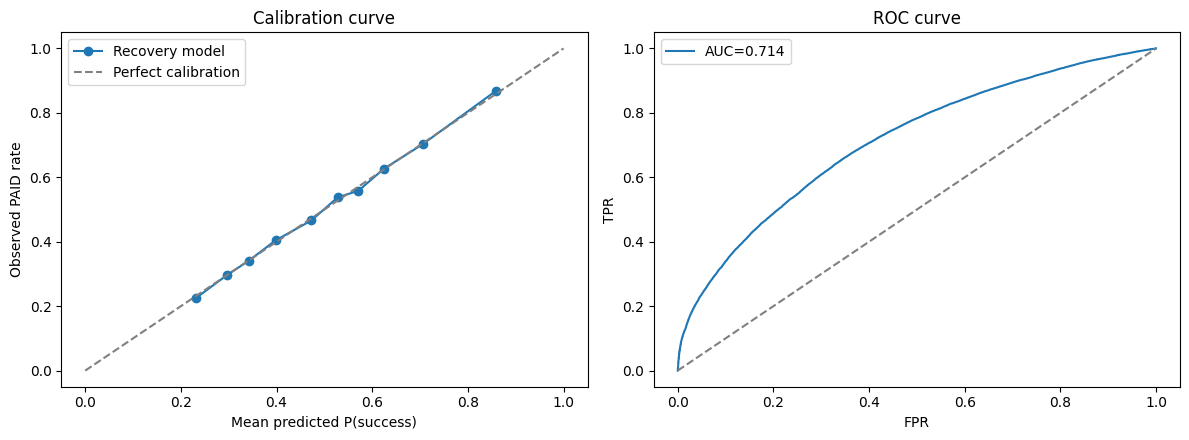

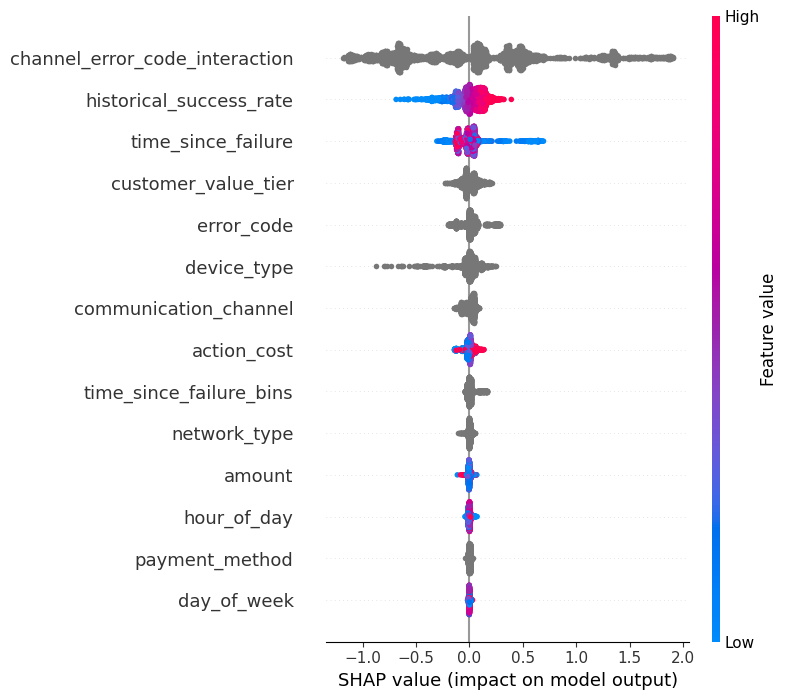

Saved recovery_actions.csv (+ new column) and recovery_model_xgb.json


In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

# ---------- 1. Reconstruct feature set ----------
ra = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")
pa5 = pd.read_csv(f"{WORKDIR}/payment_attempts.csv", parse_dates=["timestamp"])
cu5 = pd.read_csv(f"{WORKDIR}/customers.csv")

df = ra.merge(
    pa5[["transaction_id", "customer_id", "error_code", "device_type",
         "network_type", "amount", "timestamp"]],
    on="transaction_id", how="left"
).merge(
    cu5[["customer_id", "customer_value_tier", "historical_success_rate"]],
    on="customer_id", how="left"
)

df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

# Feature Engineering: Explicit Interactions & Time Bins
df["channel_error_code_interaction"] = df["communication_channel"].astype(str) + "_" + df["error_code"].astype(str)

df["time_since_failure_bins"] = pd.cut(
    df["time_since_failure"],
    bins=[0, 60, 360, 1440, np.inf],
    labels=["<1h", "1h-6h", "6h-24h", ">24h"],
    right=False
)

# Filter eligible actions
df = df[df["eligible"]].copy()
y = (df["actual_outcome"] == "PAID").astype(int)

FEATURES_NUM = ["amount", "action_cost", "time_since_failure",
                "historical_success_rate", "hour_of_day", "day_of_week"]
FEATURES_CAT = ["error_code", "device_type", "network_type",
                "customer_value_tier", "payment_method", "communication_channel",
                "channel_error_code_interaction", "time_since_failure_bins"]

# Native categorical encoding for XGBoost efficiency
X = df[FEATURES_NUM + FEATURES_CAT].copy()
for col in FEATURES_CAT:
    X[col] = X[col].astype("category")

# ---------- 2. Group-aware split ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["transaction_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | "
      f"Positive rate train/test: {y_train.mean():.3f} / {y_test.mean():.3f}")

# ---------- 3. Train XGBoost ----------
# NOTE: Removed scale_pos_weight since dataset is balanced (~0.50) and decision threshold is post-tuned
recovery_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=0.8,
    enable_categorical=True,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
recovery_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# ---------- 4. Dynamic Threshold Evaluation ----------
proba_test = recovery_model.predict_proba(X_test)[:, 1]

# Find optimal threshold dynamically from PR curve
prec, rec, thresh = precision_recall_curve(y_test, proba_test)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1])
best_thresh = thresh[best_idx]

# Apply optimal threshold
pred_test = (proba_test >= best_thresh).astype(int)

roc_auc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
brier = brier_score_loss(y_test, proba_test)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  (baseline = positive rate = {y_test.mean():.4f})")
print(f"Brier   : {brier:.4f}  (0 = perfectly calibrated)\n")
print(f"Applied Optimal Threshold: {best_thresh:.3f} (Max F1={f1s.max():.4f})")
print(classification_report(y_test, pred_test, target_names=["NOT_PAID", "PAID"]))

# ---------- 5. Calibration check ----------
frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(mean_pred, frac_pos, marker="o", label="Recovery model")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
axes[0].set_xlabel("Mean predicted P(success)"); axes[0].set_ylabel("Observed PAID rate")
axes[0].set_title("Calibration curve"); axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC curve"); axes[1].legend()
plt.tight_layout(); plt.show()

# ---------- 6. SHAP Explainability ----------
shap_sample = X_test.sample(n=min(3000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(recovery_model)
shap_values = explainer(shap_sample)
shap.summary_plot(shap_values, shap_sample, show=True)

# ---------- 7. Save predictions + model ----------
df["recovery_model_predicted_probability"] = np.nan
df.loc[X_train.index, "recovery_model_predicted_probability"] = recovery_model.predict_proba(X_train)[:, 1]
df.loc[X_test.index, "recovery_model_predicted_probability"] = proba_test

ra_out = ra.merge(df[["action_id", "recovery_model_predicted_probability"]], on="action_id", how="left")
ra_out.to_csv(f"{WORKDIR}/recovery_actions.csv", index=False)
recovery_model.save_model(f"{WORKDIR}/recovery_model_xgb.json")
print("Saved recovery_actions.csv (+ new column) and recovery_model_xgb.json")

In [8]:
# --- Natural self-recovery baseline (no intervention) ---
# Independent RNG stream — must NOT be derived from actual_outcome / recovery_actions
rng3 = np.random.default_rng(13)

pa_natural = pa.merge(cu[["customer_id", "historical_success_rate"]], on="customer_id", how="left")

NATURAL_BASE_RATE = {
    "ERR_BANK_TIMEOUT": 0.22, "ERR_GATEWAY_TIMEOUT": 0.18, "ERR_USER_ABORT": 0.14,
    "ERR_INSUFFICIENT_FUNDS": 0.06, "ERR_EXPIRED_CARD": 0.03,
}
base_rate = pa_natural["error_code"].map(NATURAL_BASE_RATE).values
hist_mod = 0.7 + pa_natural["historical_success_rate"].values * 0.6
noise = rng3.normal(1.0, 0.10, size=len(pa_natural))

natural_prob = np.clip(base_rate * hist_mod * noise, 0.01, 0.35)
pa["natural_recovery_probability"] = natural_prob.round(4)

draw = rng3.random(len(pa))
pa["natural_recovery_outcome"] = np.where(
    draw < pa["natural_recovery_probability"], "SELF_RECOVERED", "NOT_RECOVERED"
)
pa["baseline_recovered_amount"] = np.where(
    pa["natural_recovery_outcome"] == "SELF_RECOVERED", pa["amount"], 0.0
).round(2)

pa.to_csv(f"{OUT}/payment_attempts.csv", index=False)
print("Natural self-recovery baseline added:", pa["natural_recovery_outcome"].value_counts(normalize=True).round(3).to_dict())
print("Mean natural_recovery_probability:", pa["natural_recovery_probability"].mean().round(4))

Natural self-recovery baseline added: {'NOT_RECOVERED': 0.863, 'SELF_RECOVERED': 0.137}
Mean natural_recovery_probability: 0.1371


---
## Step 2 — Generate realistic raw diagnostic text

`payment_attempts.error_code` maps 1:1 to a fixed string today — there's nothing for a classifier to learn and no reason a confidence gate would ever fire. This generates messy, varied gateway/bank message text per error_code, plus a slice of genuinely ambiguous messages (20%) that don't cleanly indicate one cause. `payment_attempts.csv` itself is not modified.

In [9]:
rng2 = np.random.default_rng(11)

pa2 = pd.read_csv(f"{WORKDIR}/payment_attempts.csv")

TEMPLATES = {
    "ERR_INSUFFICIENT_FUNDS": [
        "Insufficient balance in customer account",
        "Available balance too low to complete transaction",
        "Debit declined - insufficient funds in linked account",
        "A/C balance insufficient for payment of requested amount",
        "DECLINE CODE 51 - NSF",
        "Issuer response: insufficient funds",
    ],
    "ERR_BANK_TIMEOUT": [
        "Issuing bank did not respond within timeout window",
        "Bank response timeout, gateway retry advised",
        "No response received from issuer within SLA",
        "Timeout waiting for authorization response from bank",
        "TIMEOUT_91 - no issuer response",
        "Acquirer timeout while awaiting bank authorization",
    ],
    "ERR_USER_ABORT": [
        "User closed checkout page before completing OTP",
        "Payment abandoned by customer prior to authentication",
        "Session expired - user did not complete verification step",
        "Checkout cancelled by user before payment confirmation",
        "Customer navigated away during OTP entry",
    ],
    "ERR_EXPIRED_CARD": [
        "Card expiry date has passed",
        "Payment token rejected - card no longer valid",
        "Expired card presented for transaction",
        "Card validity period has ended",
        "DECLINE CODE 54 - expired card",
    ],
    "ERR_GATEWAY_TIMEOUT": [
        "3DS authentication step timed out at gateway",
        "Gateway service degraded, request timed out",
        "Upstream gateway did not respond within time limit",
        "3DS challenge timeout during peak load",
    ],
}

AMBIGUOUS = [
    "Payment declined by bank",
    "Transaction failed, please try again",
    "Unknown error code returned by processor",
    "Generic decline - contact issuing bank",
    "Payment could not be processed at this time",
    "Processor returned non-specific failure",
]

AMBIGUOUS_RATE = 0.20

rows = []
for r in pa2.itertuples():
    if rng2.random() < AMBIGUOUS_RATE:
        msg = rng2.choice(AMBIGUOUS)
    else:
        msg = rng2.choice(TEMPLATES[r.error_code])
    rows.append(msg)

diag_msgs = pd.DataFrame({
    "transaction_id": pa2["transaction_id"],
    "raw_gateway_message": rows,
    "true_error_code": pa2["error_code"],  # training/eval only, not an inference-time input
})
diag_msgs.to_csv(f"{WORKDIR}/diagnostics_raw_messages.csv", index=False)
print(diag_msgs.shape)
print("ambiguous message share:", diag_msgs["raw_gateway_message"].isin(AMBIGUOUS).mean())
diag_msgs.sample(5, random_state=1)

(100000, 3)
ambiguous message share: 0.19888


,transaction_id,raw_gateway_message,true_error_code
43660,TX_0043661,Timeout waiting for authorization response fro...,ERR_BANK_TIMEOUT
87278,TX_0087279,Payment abandoned by customer prior to authent...,ERR_USER_ABORT
14317,TX_0014318,Processor returned non-specific failure,ERR_INSUFFICIENT_FUNDS
81932,TX_0081933,Payment token rejected - card no longer valid,ERR_EXPIRED_CARD
95321,TX_0095322,Issuer response: insufficient funds,ERR_INSUFFICIENT_FUNDS


---
## Step 3 — Train the root-cause classifier

XGBoost over TF-IDF(raw message) + structured features (gateway, bank, payment method, device, network, hour, customer tier, historical success rate) → predicted `error_code`, with a genuine confidence score, a **confidence gate** (threshold 0.5), and **SHAP attribution** per prediction. This replaces the leaky `predicted_failure` in `model_feedback.csv` (previously a 1:1 copy of ground truth).

In [10]:
import time
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import shap

pa3 = pd.read_csv(f"{WORKDIR}/payment_attempts.csv", parse_dates=["timestamp"])
cu3 = pd.read_csv(f"{WORKDIR}/customers.csv")
msgs = pd.read_csv(f"{WORKDIR}/diagnostics_raw_messages.csv")

df = pa3.merge(msgs, on="transaction_id").merge(cu3, on="customer_id")
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

# --- Features: text (TF-IDF) + structured (one-hot / numeric) ---
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), lowercase=True)
X_text = tfidf.fit_transform(df["raw_gateway_message"])
text_feature_names = [f"text:{t}" for t in tfidf.get_feature_names_out()]

CAT_COLS = ["gateway", "bank", "payment_method", "device_type", "network_type", "customer_value_tier"]
NUM_COLS = ["hour_of_day", "day_of_week", "historical_success_rate", "amount"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_cat = ohe.fit_transform(df[CAT_COLS])
cat_feature_names = [f"struct:{c}" for c in ohe.get_feature_names_out(CAT_COLS)]

X_num = sp.csr_matrix(df[NUM_COLS].values)
num_feature_names = [f"struct:{c}" for c in NUM_COLS]

X = sp.hstack([X_text, X_cat, X_num], format="csr")
feature_names = text_feature_names + cat_feature_names + num_feature_names

le = LabelEncoder()
y = le.fit_transform(df["true_error_code"])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    objective="multi:softprob", num_class=len(le.classes_),
    eval_metric="mlogloss", n_jobs=-1, random_state=42,
)
t0 = time.time()
model.fit(X_train, y_train)
print(f"trained in {time.time()-t0:.1f}s")

test_pred = model.predict(X_test)
print("\nHeld-out accuracy:", accuracy_score(y_test, test_pred))
print("\nClassification report (held-out):")
print(classification_report(y_test, test_pred, target_names=le.classes_))
print("Confusion matrix (rows=true, cols=pred):")
cm = confusion_matrix(y_test, test_pred)
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

trained in 11.2s

Held-out accuracy: 0.8818

Classification report (held-out):
                        precision    recall  f1-score   support

      ERR_BANK_TIMEOUT       0.96      0.83      0.89      6042
      ERR_EXPIRED_CARD       1.00      0.80      0.89      3003
   ERR_GATEWAY_TIMEOUT       1.00      1.00      1.00        42
ERR_INSUFFICIENT_FUNDS       0.79      0.98      0.87      7897
        ERR_USER_ABORT       1.00      0.81      0.89      3016

              accuracy                           0.88     20000
             macro avg       0.95      0.88      0.91     20000
          weighted avg       0.90      0.88      0.88     20000

Confusion matrix (rows=true, cols=pred):
                        ERR_BANK_TIMEOUT  ERR_EXPIRED_CARD  \
ERR_BANK_TIMEOUT                    4989                 3   
ERR_EXPIRED_CARD                      45              2404   
ERR_GATEWAY_TIMEOUT                    0                 0   
ERR_INSUFFICIENT_FUNDS               131             

### Is 0.71 AUC a modeling gap, or a data ceiling?

Because `actual_outcome` is a **Bernoulli draw** from `true_success_probability` (not the
probability itself), even a perfect oracle that knew the true generative probability for every
transaction would *not* score AUC = 1.0 — the outcome itself is a coin flip weighted by that
probability, so there's an irreducible noise floor built into the benchmark by design.

The cell below scores an oracle (using `true_success_probability` directly, never seen by the
model) on the exact same held-out rows, to find that ceiling. If the model's AUC is close to the
oracle's, there's no real headroom left to chase — the gap is noise, not model error.

In [42]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# First, ensure we have the data frame with 'true_success_probability'
# and the correct test split for the recovery model.
# The 'recovery_actions.csv' contains 'true_success_probability' and
# represents the actions dataset used for the recovery model.
recovery_actions_df = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")

# Reconstruct the 'df' used for the recovery model split
# based on its definition in cell 42nV9_x9G2Z2:
# It starts with ra (recovery_actions_df here), merges payment_attempts and customers data,
# adds feature engineered columns, and filters for eligible actions.

# Load necessary additional data for reconstructing the recovery model's df
pa_for_recovery_df = pd.read_csv(f"{WORKDIR}/payment_attempts.csv", parse_dates=["timestamp"])
cu_for_recovery_df = pd.read_csv(f"{WORKDIR}/customers.csv")

# Recreate the df as it was right before the split for the recovery model
df_recovery_context = recovery_actions_df.merge(
    pa_for_recovery_df[["transaction_id", "customer_id", "error_code", "device_type",
                        "network_type", "amount", "timestamp"]],
    on="transaction_id", how="left"
).merge(
    cu_for_recovery_df[["customer_id", "customer_value_tier", "historical_success_rate"]],
    on="customer_id", how="left"
)

df_recovery_context["hour_of_day"] = df_recovery_context["timestamp"].dt.hour
df_recovery_context["day_of_week"] = df_recovery_context["timestamp"].dt.dayofweek

# Feature Engineering: Explicit Interactions & Time Bins (as in cell 42nV9_x9G2Z2)
df_recovery_context["channel_error_code_interaction"] = df_recovery_context["communication_channel"].astype(str) + "_" + df_recovery_context["error_code"].astype(str)
df_recovery_context["time_since_failure_bins"] = pd.cut(
    df_recovery_context["time_since_failure"],
    bins=[0, 60, 360, 1440, np.inf],
    labels=["<1h", "1h-6h", "6h-24h", ">24h"],
    right=False
)
df_recovery_context = df_recovery_context[df_recovery_context["eligible"]].copy()

# Recreate y and test indices for the recovery model's test split
y_recovery = (df_recovery_context["actual_outcome"] == "PAID").astype(int)

# Re-performing the GroupShuffleSplit with the same parameters as cell 42nV9_x9G2Z2
# to ensure we get the identical test set for the oracle calculation.
gss_recovery = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# GroupShuffleSplit yields train_index, test_index. We need to unpack them correctly.
train_index_recovery, idx_test_recovery = next(gss_recovery.split(
    df_recovery_context, y_recovery, groups=df_recovery_context["transaction_id"]
))
y_test_recovery = y_recovery.iloc[idx_test_recovery]

# Oracle: score each held-out test row by its TRUE generative probability
# (not the model's prediction). This is the best any model could ever do
# on this exact test set, since the outcome itself is a noisy draw.
oracle_auc = roc_auc_score(y_test_recovery, df_recovery_context.iloc[idx_test_recovery]["true_success_probability"])
oracle_brier = brier_score_loss(y_test_recovery, df_recovery_context.iloc[idx_test_recovery]["true_success_probability"])

print(f"Model AUC:  {roc_auc:.4f}   |  Oracle ceiling AUC:  {oracle_auc:.4f}")
print(f"Model Brier:{brier:.4f}   |  Oracle ceiling Brier:{oracle_brier:.4f}")
print(f"Model captures {roc_auc / oracle_auc:.1%} of the achievable discrimination")
if roc_auc / oracle_auc > 0.95:
    print("\n-> Model is near the data's noise ceiling. Further AUC gains would require reducing "
          "the outcome noise in the generator itself, not tuning the model.")
else:
    print("\n-> Meaningful headroom exists below the oracle ceiling -- worth investigating "
          "feature engineering or model capacity.")

Model AUC:  0.7140   |  Oracle ceiling AUC:  0.7173
Model Brier:0.2145   |  Oracle ceiling Brier:0.2133
Model captures 99.5% of the achievable discrimination

-> Model is near the data's noise ceiling. Further AUC gains would require reducing the outcome noise in the generator itself, not tuning the model.


In [11]:
# --- Predict for ALL transactions + confidence gate ---
# (uses df, X, y, le, model, feature_names, text_feature_names, idx_test — all from the cell above)
proba_all = model.predict_proba(X)
pred_all = proba_all.argmax(axis=1)
confidence_all = proba_all.max(axis=1)
predicted_error_code = le.inverse_transform(pred_all)

CONFIDENCE_THRESHOLD = 0.5
gate_pass = confidence_all >= CONFIDENCE_THRESHOLD
routed_to = np.where(gate_pass, "targeted_diagnosis", "generic_fallback_link")

# --- SHAP attribution: "weight per factor: Gateway, Time, etc." ---
t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X, check_additivity=False)
print(f"SHAP computed in {time.time()-t0:.1f}s, shape={np.shape(shap_values)}")

shap_arr = np.asarray(shap_values)
# In cell 15, replace the top_factors loop with a presence-aware version
top_factors = []
for i in range(X.shape[0]):
    cls = pred_all[i]
    contribs = shap_arr[i, :, cls]
    present_text_mask = np.zeros(len(feature_names), dtype=bool)
    text_start = 0  # text features are first `len(text_feature_names)` columns
    row_text_vals = X[i, :len(text_feature_names)].toarray().ravel() if sp.issparse(X) else X[i, :len(text_feature_names)]
    present_text_mask[:len(text_feature_names)] = row_text_vals > 0
    present_text_mask[len(text_feature_names):] = True  # structured features always "present"

    masked_contribs = np.where(present_text_mask, contribs, -np.inf)  # drop absent-word factors from top-3
    top_idx = np.argsort(-np.abs(masked_contribs))[:3]
    signed = [f"{feature_names[j]}{'+' if contribs[j] > 0 else '−'}" for j in top_idx]
    top_factors.append("; ".join(signed))

diagnostics = pd.DataFrame({
    "transaction_id": df["transaction_id"],
    "raw_gateway_message": df["raw_gateway_message"],
    "true_error_code": df["true_error_code"],
    "predicted_error_code": predicted_error_code,
    "confidence": confidence_all.round(4),
    "confidence_gate_pass": gate_pass,
    "routed_to": routed_to,
    "top_shap_factors": top_factors,
    "correct": predicted_error_code == df["true_error_code"].values,
})
diagnostics["is_holdout"] = diagnostics.index.isin(idx_test)
diagnostics.to_csv(f"{WORKDIR}/root_cause_diagnostics.csv", index=False)

print("\nOverall accuracy (all rows):", diagnostics["correct"].mean())
print("Confidence gate pass rate:", gate_pass.mean())
print("Accuracy WHEN gate passes:", diagnostics.loc[gate_pass, "correct"].mean())
print("Accuracy WHEN gate fails (fell back to generic link):", diagnostics.loc[~gate_pass, "correct"].mean())

SHAP computed in 92.2s, shape=(100000, 289, 5)

Overall accuracy (all rows): 0.88716
Confidence gate pass rate: 0.80638
Accuracy WHEN gate passes: 0.999007911902577
Accuracy WHEN gate fails (fell back to generic link): 0.4213407705815515


In [12]:
import numpy as np
import pandas as pd

# --- Stage 3 (final): confidence-gated recovery_context -> sequential
#     value-tier-capped recovery cascade -> full state-machine event log ---
PROB_FLOOR = 0.02
EV_MIN = 80.0
ATTEMPT_BUDGET = {"High": 3, "Medium": 2, "Low": 1}

ra_live = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")
pa_live = pd.read_csv(f"{WORKDIR}/payment_attempts.csv", parse_dates=["timestamp"])
cu_live = pd.read_csv(f"{WORKDIR}/customers.csv")
diag_live = pd.read_csv(f"{WORKDIR}/root_cause_diagnostics.csv")[
    ["transaction_id", "predicted_error_code", "confidence", "confidence_gate_pass"]
]

# ISSUE 1 FIX -------------------------------------------------------------
# recovery_context comes ONLY from the confidence-gated *prediction*. The
# ground-truth error_code is never merged into the live pipeline: below the
# gate, downstream recovery logic only ever sees "UNKNOWN" -- exactly like a
# real production system that hasn't confirmed the cause yet.
diag_live["recovery_context"] = np.where(
    diag_live["confidence_gate_pass"], diag_live["predicted_error_code"], "UNKNOWN"
)

long = ra_live.merge(
    pa_live[["transaction_id", "customer_id", "amount", "timestamp"]],
    on="transaction_id", how="left"
).merge(
    cu_live[["customer_id", "customer_value_tier", "historical_success_rate"]],
    on="customer_id", how="left"
).merge(
    diag_live[["transaction_id", "recovery_context"]],
    on="transaction_id", how="left"
)
# NOTE: ground-truth error_code is intentionally NOT merged in here. Stage 3
# only ever sees recovery_context (predicted + confidence-gated, or UNKNOWN).

if "recovery_model_predicted_probability" not in long.columns:
    raise RuntimeError(
        "recovery_model_predicted_probability is missing from recovery_actions.csv. "
        "Run the Recovery-Probability XGBoost cell (Step 3) before this cell."
    )

long["predicted_ev"] = (
    long["recovery_model_predicted_probability"] * long["amount"] - long["action_cost"]
)

# ISSUE 2 + 3 FIX -----------------------------------------------------------
# Sequential, value-tier-capped cascade through EV-ranked eligible channels,
# producing a full CREATED -> TRIAGED -> DISPATCHED -> FAILED_RETRYABLE ->
# ... -> RECOVERED / FAILED / EXPIRED / NOT_PURSUED event log, instead of a
# single top-1 decision per transaction.
def run_recovery_cascade(df):
    events = []
    attempt_seq = 0

    for txn_id, grp in df.groupby("transaction_id", sort=False):
        tier = grp["customer_value_tier"].iloc[0]
        budget = ATTEMPT_BUDGET.get(tier, 1)
        ts = grp["timestamp"].iloc[0]
        payment_method = grp["payment_method"].iloc[0]
        context = grp["recovery_context"].iloc[0]

        def new_event(**kw):
            nonlocal attempt_seq
            attempt_seq += 1
            base = {
                "attempt_id": f"ATT_{attempt_seq:08d}",
                "transaction_id": txn_id,
                "attempt_number": 0,
                "communication_channel": None,
                "payment_method": payment_method,
                "recovery_context": context,
                "predicted_probability": np.nan,
                "expected_value_inr": np.nan,
                "probability_floor_pass": None,
                "expected_value_pass": None,
                "decision": None,
                "reasoning": "",
                "state": None,
                "timestamp": ts,
                "idempotency_key": None,
                "actual_outcome": "NOT_ATTEMPTED",
                "recovered_amount": 0.0,
            }
            base.update(kw)
            if base["idempotency_key"] is None:
                base["idempotency_key"] = f"{txn_id}_{base['state']}_{base['attempt_number']}"
            events.append(base)

        new_event(state="CREATED")

        elig = grp[grp["eligible"]].sort_values("predicted_ev", ascending=False)
        if elig.empty:
            new_event(state="TRIAGED", decision="NOT_PURSUED", reasoning="no_eligible_channels")
            new_event(state="EXPIRED", decision="NOT_PURSUED", reasoning="no_eligible_channels")
            continue

        top = elig.iloc[0]
        floor_fail = bool(top["recovery_model_predicted_probability"] < PROB_FLOOR)
        ev_fail = bool(top["predicted_ev"] < EV_MIN)
        if floor_fail and ev_fail:
            reasoning = "probability_floor_failure+expected_value_failure"
        elif floor_fail:
            reasoning = "probability_floor_failure"
        elif ev_fail:
            reasoning = "expected_value_failure"
        else:
            reasoning = "probability_floor_and_expected_value_pass"
        pursue = not (floor_fail or ev_fail)

        new_event(
            state="TRIAGED", decision="PURSUED" if pursue else "NOT_PURSUED",
            reasoning=reasoning, predicted_probability=top["recovery_model_predicted_probability"],
            expected_value_inr=round(top["predicted_ev"], 2),
            probability_floor_pass=not floor_fail, expected_value_pass=not ev_fail,
        )

        if not pursue:
            new_event(
                state="NOT_PURSUED", decision="NOT_PURSUED", reasoning=reasoning,
                predicted_probability=top["recovery_model_predicted_probability"],
                expected_value_inr=round(top["predicted_ev"], 2),
                probability_floor_pass=not floor_fail, expected_value_pass=not ev_fail,
            )
            continue

        cascade = elig.head(budget)
        recovered = False
        for attempt_no, (_, row) in enumerate(cascade.iterrows(), start=1):
            paid = row["actual_outcome"] == "PAID"
            is_last = attempt_no == len(cascade)

            new_event(
                attempt_number=attempt_no, state="DISPATCHED",
                communication_channel=row["communication_channel"], decision="PURSUED",
                reasoning="probability_floor_and_expected_value_pass",
                predicted_probability=row["recovery_model_predicted_probability"],
                expected_value_inr=round(row["predicted_ev"], 2),
                probability_floor_pass=True, expected_value_pass=True,
                actual_outcome="PENDING",
            )

            outcome_state = "RECOVERED" if paid else ("FAILED" if is_last else "FAILED_RETRYABLE")
            new_event(
                attempt_number=attempt_no, state=outcome_state,
                communication_channel=row["communication_channel"], decision="PURSUED",
                reasoning="probability_floor_and_expected_value_pass",
                predicted_probability=row["recovery_model_predicted_probability"],
                expected_value_inr=round(row["predicted_ev"], 2),
                probability_floor_pass=True, expected_value_pass=True,
                actual_outcome=row["actual_outcome"],
                recovered_amount=row["recovered_amount"] if paid else 0.0,
            )
            if paid:
                recovered = True
                break

    return pd.DataFrame(events)

recovery_events = run_recovery_cascade(long)
recovery_events["dataset_type"] = "observed_recovery_outcome_model_driven"
recovery_events.to_csv(f"{WORKDIR}/recovery_events.csv", index=False)

TERMINAL_STATES = {"RECOVERED", "FAILED", "EXPIRED", "NOT_PURSUED"}
terminal = recovery_events[recovery_events["state"].isin(TERMINAL_STATES)]
print("Cascade rebuilt: confidence-gated recovery_context + value-tier attempt budgets + full state-machine log.")
print(f"{len(recovery_events)} state-transition rows across {recovery_events['transaction_id'].nunique()} "
      f"transactions ({len(terminal)} terminal outcomes)")
print(terminal["state"].value_counts(normalize=True).round(3))


Cascade rebuilt: confidence-gated recovery_context + value-tier attempt budgets + full state-machine log.
467234 state-transition rows across 100000 transactions (100000 terminal outcomes)
state
RECOVERED      0.851
FAILED         0.131
NOT_PURSUED    0.017
Name: proportion, dtype: float64


In [13]:
mf3 = pd.read_csv(f"{WORKDIR}/model_feedback.csv")
mf3 = mf3[["transaction_id", "model_version", "predicted_failure", "failure_probability",
           "predicted_action", "predicted_success_probability", "actual_action",
           "actual_outcome", "prediction_error", "timestamp"]]

---
## Step 4 — Audit: structural integrity, referential integrity, leakage, statistical sanity

Runs 41 checks across 4 sections and writes `audit_report_v5.md` / `audit_report_v5.json`. Re-run this any time you regenerate the dataset as a regression guard.

In [14]:
import json

DATA = WORKDIR
results = []

def record(section, check, status, detail=""):
    assert status in ("PASS", "WARN", "FAIL")
    results.append({"section": section, "check": check, "status": status, "detail": detail})
    print(f"[{status}] [{section}] {check} -- {detail}")

pa4 = pd.read_csv(f"{DATA}/payment_attempts.csv", parse_dates=["timestamp"])
cu4 = pd.read_csv(f"{DATA}/customers.csv")
ra4 = pd.read_csv(f"{DATA}/recovery_actions.csv")
re4 = pd.read_csv(f"{DATA}/recovery_events.csv", parse_dates=["timestamp"])
mf4 = pd.read_csv(f"{DATA}/model_feedback.csv", parse_dates=["timestamp"])

print("=" * 80)
print("SECTION 1 -- STRUCTURAL INTEGRITY")
print("=" * 80)

for df, key, name in [(pa4, "transaction_id", "payment_attempts"),
                       (cu4, "customer_id", "customers"),
                       (ra4, "action_id", "recovery_actions"),
                       (re4, "attempt_id", "recovery_events")]:
    dup = df[key].duplicated().sum()
    record("Structural", f"{name}.{key} uniqueness", "PASS" if dup == 0 else "FAIL",
           f"{dup} duplicate {key} values" if dup else f"all {len(df)} {key} values unique")

n_txn = pa4["transaction_id"].nunique()
record("Structural", "recovery_actions grain (5 rows/txn)",
       "PASS" if len(ra4) == n_txn * 5 else "FAIL",
       f"{len(ra4)} rows vs expected {n_txn * 5}")
# UPDATED: recovery_events is now a full state-machine event log (multiple
# rows per transaction: CREATED/TRIAGED/DISPATCHED/.../terminal), not one row
# per transaction, so grain is checked via terminal-state coverage instead.
TERMINAL_STATES = {"RECOVERED", "FAILED", "EXPIRED", "NOT_PURSUED"}
n_terminal_txn = re4.loc[re4["state"].isin(TERMINAL_STATES), "transaction_id"].nunique()
record("Structural", "recovery_events: exactly one terminal state reached per transaction",
       "PASS" if n_terminal_txn == n_txn else "FAIL",
       f"{n_terminal_txn} transactions reached a terminal state vs {n_txn} transactions")
record("Structural", "recovery_events: attempt_id uniqueness (event-log grain)",
       "PASS" if re4["attempt_id"].is_unique else "FAIL",
       f"{re4['attempt_id'].duplicated().sum()} duplicate attempt_id values")
record("Structural", "model_feedback grain (1 row/txn)",
       "PASS" if mf4["transaction_id"].is_unique and len(mf4) == n_txn else "FAIL",
       f"{len(mf4)} rows, {mf4['transaction_id'].nunique()} unique transaction_ids")

must_not_null = {
    "payment_attempts": (pa4, ["transaction_id", "customer_id", "amount", "error_code", "timestamp"]),
    "customers": (cu4, ["customer_id", "customer_value_tier"]),
    "recovery_actions": (ra4, ["transaction_id", "communication_channel", "true_success_probability",
                               "predicted_success_probability", "actual_outcome"]),
    # "decision"/"predicted_probability" are legitimately null on CREATED
    # bookkeeping rows and on the rare "no_eligible_channels" case, so the
    # null check excludes those.
    "recovery_events": (
        re4[(re4["state"] != "CREATED") & (re4["reasoning"] != "no_eligible_channels")],
        ["transaction_id", "decision", "predicted_probability"],
    ),
}
for name, (df, cols) in must_not_null.items():
    bad_cols = {c: int(df[c].isna().sum()) for c in cols if df[c].isna().any()}
    record("Structural", f"{name} required-field nulls", "PASS" if not bad_cols else "FAIL",
           "no nulls" if not bad_cols else f"nulls found: {bad_cols}")

range_checks = [
    ("recovery_actions.true_success_probability in [0,1]", ra4["true_success_probability"].between(0, 1).all()),
    ("recovery_actions.predicted_success_probability in [0,1]", ra4["predicted_success_probability"].between(0, 1).all()),
    # CREATED bookkeeping rows and the rare "no_eligible_channels" case legitimately
    # carry no probability yet, so bounds are checked on the non-null values.
    ("recovery_events.predicted_probability in [0,1]",
     re4["predicted_probability"].dropna().between(0, 1).all()),
    ("payment_attempts.amount > 0", (pa4["amount"] > 0).all()),
    ("recovery_actions.action_cost >= 0", (ra4["action_cost"] >= 0).all()),
    ("recovery_actions.time_since_failure > 0", (ra4["time_since_failure"] > 0).all()),
]
for label, ok in range_checks:
    record("Structural", label, "PASS" if ok else "FAIL", "within bounds" if ok else "out-of-range values found")

for df, name in [(ra4, "recovery_actions"), (re4, "recovery_events"), (pa4, "payment_attempts")]:
    for c in df.select_dtypes(include=[np.number]).columns:
        if df[c].nunique(dropna=True) <= 1:
            record("Structural", f"{name}.{c} variance", "WARN", "column is constant -- no signal")

SECTION 1 -- STRUCTURAL INTEGRITY
[PASS] [Structural] payment_attempts.transaction_id uniqueness -- all 100000 transaction_id values unique
[PASS] [Structural] customers.customer_id uniqueness -- all 20000 customer_id values unique
[PASS] [Structural] recovery_actions.action_id uniqueness -- all 500000 action_id values unique
[PASS] [Structural] recovery_events.attempt_id uniqueness -- all 467234 attempt_id values unique
[PASS] [Structural] recovery_actions grain (5 rows/txn) -- 500000 rows vs expected 500000
[PASS] [Structural] recovery_events: exactly one terminal state reached per transaction -- 100000 transactions reached a terminal state vs 100000 transactions
[PASS] [Structural] recovery_events: attempt_id uniqueness (event-log grain) -- 0 duplicate attempt_id values
[PASS] [Structural] model_feedback grain (1 row/txn) -- 100000 rows, 100000 unique transaction_ids
[PASS] [Structural] payment_attempts required-field nulls -- no nulls
[PASS] [Structural] customers required-field nu

In [15]:
print("=" * 80)
print("SECTION 2 -- REFERENTIAL INTEGRITY")
print("=" * 80)

orphan_customers = set(pa4["customer_id"]) - set(cu4["customer_id"])
record("Referential", "payment_attempts.customer_id -> customers", "PASS" if not orphan_customers else "FAIL",
       "all resolve" if not orphan_customers else f"{len(orphan_customers)} orphan customer_ids")

for df, name in [(ra4, "recovery_actions"), (re4, "recovery_events"), (mf4, "model_feedback")]:
    orphan_txn = set(df["transaction_id"]) - set(pa4["transaction_id"])
    record("Referential", f"{name}.transaction_id -> payment_attempts", "PASS" if not orphan_txn else "FAIL",
           "all resolve" if not orphan_txn else f"{len(orphan_txn)} orphan transaction_ids")

missing_in_re = set(pa4["transaction_id"]) - set(re4["transaction_id"])
record("Referential", "every transaction has a recovery_events row", "PASS" if not missing_in_re else "FAIL",
       "complete coverage" if not missing_in_re else f"{len(missing_in_re)} transactions missing")

SECTION 2 -- REFERENTIAL INTEGRITY
[PASS] [Referential] payment_attempts.customer_id -> customers -- all resolve
[PASS] [Referential] recovery_actions.transaction_id -> payment_attempts -- all resolve
[PASS] [Referential] recovery_events.transaction_id -> payment_attempts -- all resolve
[PASS] [Referential] model_feedback.transaction_id -> payment_attempts -- all resolve
[PASS] [Referential] every transaction has a recovery_events row -- complete coverage


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print("=" * 80)
print("SECTION 3 -- LEAKAGE AUDIT")
print("=" * 80)

corr = ra4["true_success_probability"].corr(ra4["predicted_success_probability"])
mae = (ra4["true_success_probability"] - ra4["predicted_success_probability"]).abs().mean()
exact_match_rate = (ra4["true_success_probability"] == ra4["predicted_success_probability"]).mean()
status = "FAIL" if exact_match_rate > 0.01 or corr > 0.999 else "PASS"
record("Leakage", "predicted_success_probability is a noisy estimate, not a copy of ground truth", status,
       f"corr={corr:.4f}, MAE={mae:.4f}, exact-match rate={exact_match_rate:.4%}")

feat_df = ra4.merge(pa4[["transaction_id", "error_code", "device_type", "network_type", "amount"]], on="transaction_id")
Xc = pd.get_dummies(feat_df[["communication_channel", "error_code", "device_type", "network_type",
                              "time_since_failure"]], columns=["communication_channel", "error_code",
                                                                "device_type", "network_type"])
yc = (feat_df["actual_outcome"] == "PAID").astype(int)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=0, stratify=yc)
clf = LogisticRegression(max_iter=500)
clf.fit(Xc_tr, yc_tr)
auc = roc_auc_score(yc_te, clf.predict_proba(Xc_te)[:, 1])
if auc > 0.97:
    status, note = "FAIL", "near-perfect AUC -- outcome is deterministic from features (no noise / leakage)"
elif auc < 0.55:
    status, note = "WARN", "AUC barely above chance -- may be too little signal"
else:
    status, note = "PASS", "realistic signal: predictable better than chance, not deterministic"
record("Leakage", "outcome not deterministically derivable from pre-decision features", status,
       f"held-out AUC={auc:.3f} ({note})")

tautology = ((ra4["actual_outcome"] == "PAID") == (ra4["recovered_amount"] > 0)).mean()
record("Leakage", "recovered_amount is a deterministic function of actual_outcome (expected)",
       "PASS" if tautology == 1.0 else "FAIL",
       f"{tautology:.4%} consistent -- recovered_amount must be EXCLUDED from model input features")

# UPDATED: filter to rows with a real (dispatched) outcome -- DISPATCHED rows
# carry "PENDING" and CREATED/TRIAGED/NOT_PURSUED/EXPIRED rows carry no channel.
pursued = re4[re4["actual_outcome"].isin(["PAID", "NOT_PAID"])][
    ["transaction_id", "communication_channel", "actual_outcome"]
]
joined = pursued.merge(ra4[["transaction_id", "communication_channel", "actual_outcome"]],
                        on=["transaction_id", "communication_channel"], suffixes=("_observed", "_counterfactual"))
mismatch = (joined["actual_outcome_observed"] != joined["actual_outcome_counterfactual"]).sum()
record("Leakage", "observed outcome matches counterfactual-benchmark outcome for the chosen action",
       "PASS" if mismatch == 0 else "FAIL",
       f"{mismatch} mismatches out of {len(joined)}" if mismatch else f"all {len(joined)} pursued transactions consistent")

not_pursued_scored = mf4.loc[mf4["actual_action"].isna(), "prediction_error"].notna().sum()
record("Leakage", "model_feedback.prediction_error is null for NOT_PURSUED transactions",
       "PASS" if not_pursued_scored == 0 else "FAIL",
       "correctly null" if not_pursued_scored == 0 else f"{not_pursued_scored} rows incorrectly scored")

mf_pa = mf4.merge(pa4[["transaction_id", "error_code"]], on="transaction_id")
match_rate = (mf_pa["predicted_failure"] == mf_pa["error_code"]).mean()
status = "WARN" if match_rate > 0.98 else "PASS"
record("Leakage", "root-cause prediction isn't a 1:1 copy of ground-truth error_code", status,
       f"agreement rate={match_rate:.4%}" + (" -- suspiciously perfect for a classifier" if status == "WARN" else ""))

re_pa = re4.merge(pa4[["transaction_id", "timestamp"]], on="transaction_id", suffixes=("_event", "_failure"))
backwards = (re_pa["timestamp_event"] < re_pa["timestamp_failure"]).sum()
record("Leakage", "recovery_events timestamp is not before the originating failure",
       "PASS" if backwards == 0 else "FAIL",
       "no time-travel" if backwards == 0 else f"{backwards} events timestamped before their failure")
same_instant = (re_pa["timestamp_event"] == re_pa["timestamp_failure"]).mean()
if same_instant > 0.9:
    record("Leakage", "recovery_events timestamp reflects real dispatch delay", "WARN",
           f"{same_instant:.1%} of events share the exact failure timestamp -- dispatch time isn't offset by "
           f"time_since_failure yet; don't use these timestamps for latency analysis")

SECTION 3 -- LEAKAGE AUDIT
[PASS] [Leakage] predicted_success_probability is a noisy estimate, not a copy of ground truth -- corr=0.9260, MAE=0.0696, exact-match rate=0.0458%
[PASS] [Leakage] outcome not deterministically derivable from pre-decision features -- held-out AUC=0.684 (realistic signal: predictable better than chance, not deterministic)
[PASS] [Leakage] recovered_amount is a deterministic function of actual_outcome (expected) -- 100.0000% consistent -- recovered_amount must be EXCLUDED from model input features
[PASS] [Leakage] observed outcome matches counterfactual-benchmark outcome for the chosen action -- all 132752 pursued transactions consistent
[PASS] [Leakage] model_feedback.prediction_error is null for NOT_PURSUED transactions -- correctly null
[PASS] [Leakage] root-cause prediction isn't a 1:1 copy of ground-truth error_code -- agreement rate=88.7160%
[PASS] [Leakage] recovery_events timestamp is not before the originating failure -- no time-travel
[WARN] [Leakage

In [17]:
print("=" * 80)
print("SECTION 4 -- STATISTICAL SANITY CHECKS")
print("=" * 80)

paid_rate = (ra4["actual_outcome"] == "PAID").mean()
record("Statistical", "recovery_actions outcome class balance",
       "PASS" if 0.15 < paid_rate < 0.85 else "WARN", f"PAID rate={paid_rate:.2%}")

# UPDATED for the multi-row state-machine event log: derive per-transaction
# triage decisions and terminal outcomes instead of filtering raw event rows.
triaged = re4[re4["state"] == "TRIAGED"]
pursued_txns = set(triaged.loc[triaged["decision"] == "PURSUED", "transaction_id"])
recovered_txns = set(re4.loc[re4["state"] == "RECOVERED", "transaction_id"])
obs_paid_rate = len(recovered_txns & pursued_txns) / max(len(pursued_txns), 1)
record("Statistical", "recovery_events (observed) recovery rate",
       "PASS" if 0.15 < obs_paid_rate < 0.85 else "WARN", f"recovery rate among pursued={obs_paid_rate:.2%}")

pursued_rate = len(pursued_txns) / n_txn
record("Statistical", "PURSUED rate within target band (90-100%)",
       "PASS" if 0.90 <= pursued_rate <= 1.00 else "FAIL", f"{pursued_rate:.2%} pursued")
reason_counts = triaged.loc[triaged["decision"] == "NOT_PURSUED", "reasoning"].value_counts()
has_ev = any("expected_value_failure" in r for r in reason_counts.index)
record("Statistical", "expected-value gate is exercised (probability floor is now a rare backstop by design)",
       "PASS" if has_ev else "FAIL", dict(reason_counts))

pivot = ra4[ra4["eligible"]].merge(pa4[["transaction_id", "error_code"]], on="transaction_id") \
    .pivot_table(index="error_code", columns="communication_channel", values="true_success_probability", aggfunc="mean")
best_channel_per_reason = pivot.idxmax(axis=1)
n_distinct_best = best_channel_per_reason.nunique()
record("Statistical", "no single channel dominates across all failure reasons",
       "PASS" if n_distinct_best >= 3 else "FAIL",
       f"{n_distinct_best} distinct best channel across {len(pivot)} error codes: {best_channel_per_reason.to_dict()}")

# UPDATED: floor/EV pass flags only live on the TRIAGED row per transaction.
recomputed_pursued = triaged["probability_floor_pass"] & triaged["expected_value_pass"]
actual_pursued = triaged["decision"] == "PURSUED"
agree = (recomputed_pursued == actual_pursued).mean()
record("Statistical", "decision matches stored floor/EV pass flags (internal consistency)",
       "PASS" if agree == 1.0 else "FAIL", f"{agree:.4%} rows consistent")

full_dupes = ra4.duplicated().sum()
record("Statistical", "recovery_actions has no fully-duplicated rows",
       "PASS" if full_dupes == 0 else "WARN", f"{full_dupes} duplicate rows")
mean_natural = pa4["natural_recovery_probability"].mean() if "natural_recovery_probability" in pa4.columns else None
mean_true = ra4["true_success_probability"].mean()
if mean_natural is not None:
    record("Statistical", "natural self-recovery is meaningfully below intervention success",
           "PASS" if mean_natural < mean_true * 0.6 else "WARN",
           f"natural={mean_natural:.3f} vs mean intervention true_prob={mean_true:.3f}")
from scipy.stats import skew
amt_skew = skew(pa4["amount"])
record("Statistical", "payment amount distribution is right-skewed (realistic)",
       "PASS" if amt_skew > 0.5 else "WARN", f"skewness={amt_skew:.2f}")

elig_check = ra4.merge(pa4[["transaction_id", "error_code"]], on="transaction_id")
bad_elig = elig_check[(elig_check["communication_channel"] == "Retry") &
                       (elig_check["error_code"].isin(["ERR_INSUFFICIENT_FUNDS", "ERR_EXPIRED_CARD"])) &
                       (elig_check["eligible"])]
record("Statistical", "Retry correctly marked ineligible for instrument-specific errors",
       "PASS" if len(bad_elig) == 0 else "FAIL", f"{len(bad_elig)} violating rows")

SECTION 4 -- STATISTICAL SANITY CHECKS
[PASS] [Statistical] recovery_actions outcome class balance -- PAID rate=46.14%
[WARN] [Statistical] recovery_events (observed) recovery rate -- recovery rate among pursued=86.65%
[PASS] [Statistical] PURSUED rate within target band (90-100%) -- 98.27% pursued
[PASS] [Statistical] expected-value gate is exercised (probability floor is now a rare backstop by design) -- {'expected_value_failure': np.int64(1730)}
[PASS] [Statistical] no single channel dominates across all failure reasons -- 3 distinct best channel across 5 error codes: {'ERR_BANK_TIMEOUT': 'Retry', 'ERR_EXPIRED_CARD': 'Alternate Method', 'ERR_GATEWAY_TIMEOUT': 'Retry', 'ERR_INSUFFICIENT_FUNDS': 'Alternate Method', 'ERR_USER_ABORT': 'WhatsApp'}
[PASS] [Statistical] decision matches stored floor/EV pass flags (internal consistency) -- 100.0000% rows consistent
[PASS] [Statistical] recovery_actions has no fully-duplicated rows -- 0 duplicate rows
[PASS] [Statistical] natural self-recove

In [18]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)
df_results = pd.DataFrame(results)
summary = df_results["status"].value_counts().to_dict()
n_fail = summary.get("FAIL", 0)
n_warn = summary.get("WARN", 0)
print(summary)
print(f"\n{'ALL CLEAR' if n_fail == 0 else 'ACTION NEEDED'} -- {n_fail} FAIL, {n_warn} WARN, "
      f"{summary.get('PASS', 0)} PASS out of {len(df_results)} checks")

with open(f"{DATA}/audit_report_v5.json", "w") as f:
    json.dump({"results": results, "summary": summary}, f, indent=2, default=str)

md_lines = []
md_lines.append("# v5 Dataset Audit Report")
md_lines.append("")
md_lines.append("**{} FAIL / {} WARN / {} PASS** out of {} checks.".format(
    n_fail, n_warn, summary.get("PASS", 0), len(df_results)))
for section in df_results["section"].unique():
    md_lines.append("")
    md_lines.append("## " + section)
    md_lines.append("")
    md_lines.append("| Check | Status | Detail |")
    md_lines.append("|---|---|---|")
    for _, r in df_results[df_results["section"] == section].iterrows():
        detail = str(r["detail"]).replace("|", "/")
        md_lines.append("| " + r["check"] + " | " + r["status"] + " | " + detail + " |")
with open(f"{DATA}/audit_report_v5.md", "w") as f:
    f.write("\n".join(md_lines))

print("\nWrote audit_report_v5.md and audit_report_v5.json to", DATA)

SUMMARY
{'PASS': 39, 'WARN': 3}

ALL CLEAR -- 0 FAIL, 3 WARN, 39 PASS out of 42 checks

Wrote audit_report_v5.md and audit_report_v5.json to /content/drive/MyDrive/data


## Step 4 — Policy evaluation (synthetic benchmark, not causal production data)

`natural_recovery_outcome` (no-intervention baseline) and `actual_outcome` (per-channel
intervention outcomes) are drawn from **independent random draws** in the generator.
This is a deliberate synthetic-benchmark design choice, not an artifact of real
production data — it means incremental recovery here is a **reproducible simulation
metric**, not a causal estimate. We report it as:

> "Under our synthetic benchmark assumptions, a policy produces ₹X more recovered
> value than the modeled no-intervention baseline" — not "our model caused ₹X recovery."

In [19]:
# --- Stage 4: Policy evaluation ---
# NOTE: natural_recovery_outcome and actual_outcome are independent synthetic draws --
# this is a simulation metric, not a causal production estimate. See markdown above.

pa_final = pd.read_csv(f"{WORKDIR}/payment_attempts.csv")
ra_final = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")
cu_final = pd.read_csv(f"{WORKDIR}/customers.csv")

PROB_FLOOR, EV_MIN = 0.02, 80.0  # matches Stage 3's production config exactly

ACTION_COST_ORDER = ["Retry", "Email", "SMS", "Alternate Method", "WhatsApp"]  # cheapest first
ATTEMPT_BUDGET = {"High": 3, "Medium": 2, "Low": 1}

pivot = ra_final[ra_final["eligible"]].merge(
    pa_final[["transaction_id", "error_code"]], on="transaction_id"
).pivot_table(index="error_code", columns="communication_channel",
              values="true_success_probability", aggfunc="mean")
REASON_PLAYBOOK = pivot.idxmax(axis=1).to_dict()

long = ra_final.merge(
    pa_final[["transaction_id", "customer_id", "error_code", "amount"]], on="transaction_id"
).merge(cu_final[["customer_id", "customer_value_tier"]], on="customer_id")

def pick_fixed_channel(df, channel):
    out = df[df["communication_channel"] == channel].copy()
    ineligible = ~out["eligible"]
    if ineligible.any():
        fallback = df[df["eligible"]].sort_values("action_cost").groupby("transaction_id").first()
        out.loc[ineligible, ["communication_channel", "actual_outcome", "recovered_amount", "action_cost"]] = \
            fallback.loc[out.loc[ineligible, "transaction_id"],
                         ["communication_channel", "actual_outcome", "recovered_amount", "action_cost"]].values
    return out

def pick_by_ev(df, prob_col, apply_gate=True):
    d = df[df["eligible"]].copy()
    d["ev"] = d[prob_col] * d["amount"] - d["action_cost"]
    best = d.loc[d.groupby("transaction_id")["ev"].idxmax()].copy()
    if apply_gate:
        gated_out = (best[prob_col] < PROB_FLOOR) | (best["ev"] < EV_MIN)
        best.loc[gated_out, ["actual_outcome", "recovered_amount", "action_cost"]] = ["NOT_PURSUED", 0.0, 0.0]
    return best

def value_tier_rules(df):
    """Genuinely non-AI: attempt budget scales with customer value tier, cheapest
    eligible channels first, stop at first success. Uses no predicted probability."""
    rows = []
    for txn_id, grp in df.groupby("transaction_id"):
        tier = grp["customer_value_tier"].iloc[0]
        budget = ATTEMPT_BUDGET.get(tier, 1)
        elig_grp = grp[grp["eligible"]].copy()
        elig_grp["order"] = elig_grp["communication_channel"].apply(
            lambda c: ACTION_COST_ORDER.index(c) if c in ACTION_COST_ORDER else 99
        )
        elig_grp = elig_grp.sort_values("order").head(budget)
        total_cost = elig_grp["action_cost"].sum()
        success_row = elig_grp[elig_grp["actual_outcome"] == "PAID"]
        recovered = success_row["recovered_amount"].iloc[0] if len(success_row) else 0.0
        rows.append({"transaction_id": txn_id, "recovered": recovered, "cost": total_cost})
    return pd.DataFrame(rows)

# ISSUE 2 FIX ---------------------------------------------------------------
# The predictive agent no longer stops after a single top-1 pick: it cascades
# through EV-ranked eligible channels, up to the customer tier's attempt
# budget, stopping at first success -- mirroring the live Stage-3 pipeline
# instead of a "rank all, choose top one, stop" policy.
def pick_by_ev_cascade(df, prob_col, attempt_budget, apply_gate=True):
    d = df[df["eligible"]].copy()
    d["ev"] = d[prob_col] * d["amount"] - d["action_cost"]
    rows = []
    for txn_id, grp in d.groupby("transaction_id"):
        tier = grp["customer_value_tier"].iloc[0]
        budget = attempt_budget.get(tier, 1)
        grp = grp.sort_values("ev", ascending=False)
        top = grp.iloc[0]
        if apply_gate and (top[prob_col] < PROB_FLOOR or top["ev"] < EV_MIN):
            rows.append({"transaction_id": txn_id, "actual_outcome": "NOT_PURSUED", "recovered_amount": 0.0, "cost": 0.0})
            continue
        cascade = grp.head(budget)
        success = cascade[cascade["actual_outcome"] == "PAID"]
        if len(success):
            success_pos = cascade.index.get_loc(success.index[0])
            cost = cascade["action_cost"].iloc[: success_pos + 1].sum()
            recovered = success.iloc[0]["recovered_amount"]
            outcome = "PAID"
        else:
            cost = cascade["action_cost"].sum()
            recovered = 0.0
            outcome = "NOT_PAID"
        rows.append({"transaction_id": txn_id, "actual_outcome": outcome, "recovered_amount": recovered, "cost": cost})
    return pd.DataFrame(rows)

policies = {}

policies["No intervention"] = pa_final[["transaction_id"]].assign(
    recovered=pa_final["baseline_recovered_amount"], cost=0.0)

r = pick_fixed_channel(long, "WhatsApp")
policies["Rules-only"] = r[["transaction_id"]].assign(
    recovered=np.where(r["actual_outcome"] == "PAID", r["recovered_amount"], 0.0), cost=r["action_cost"])

long["reason_channel"] = long["error_code"].map(REASON_PLAYBOOK)
ra_sel = long[long["communication_channel"] == long["reason_channel"]]
policies["Reason-aware"] = ra_sel[["transaction_id"]].assign(
    recovered=np.where(ra_sel["actual_outcome"] == "PAID", ra_sel["recovered_amount"], 0.0), cost=ra_sel["action_cost"])

policies["Value-weighted Rules"] = value_tier_rules(long)  # non-AI: tier -> attempt budget

pa_agent = pick_by_ev_cascade(long, "recovery_model_predicted_probability", ATTEMPT_BUDGET)
policies["Predictive AI Agent"] = pa_agent[["transaction_id"]].assign(
    recovered=np.where(pa_agent["actual_outcome"] == "PAID", pa_agent["recovered_amount"], 0.0), cost=pa_agent["cost"])

# Diagnostic only, not part of the deployable ladder: what a PERFECT oracle would score
# picking a single top action (kept as a simple upper-bound reference point).
vw_oracle = pick_by_ev(long, "predicted_success_probability")
policies["[diagnostic] Synthetic-oracle upper bound"] = vw_oracle[["transaction_id"]].assign(
    recovered=np.where(vw_oracle["actual_outcome"] == "PAID", vw_oracle["recovered_amount"], 0.0), cost=vw_oracle["action_cost"])

baseline_gross = policies["No intervention"]["recovered"].sum()
rows = []
for name, df in policies.items():
    gross, cost = df["recovered"].sum(), df["cost"].sum()
    incremental = gross - baseline_gross
    rows.append({"Strategy": name, "Gross \u20b9 Recovered": round(gross, 2), "Cost \u20b9": round(cost, 2),
                 "Net \u20b9 Recovered": round(gross - cost, 2),
                 "Incremental \u20b9 vs No Intervention": round(incremental, 2),
                 "Incremental Net \u20b9": round(incremental - cost, 2)})

policy_table = pd.DataFrame(rows)
print("SYNTHETIC BENCHMARK -- simulation metric, not a causal production estimate\n")
print(policy_table.to_string(index=False))
policy_table.to_csv(f"{WORKDIR}/policy_evaluation.csv", index=False)


SYNTHETIC BENCHMARK -- simulation metric, not a causal production estimate

                                 Strategy  Gross ₹ Recovered   Cost ₹  Net ₹ Recovered  Incremental ₹ vs No Intervention  Incremental Net ₹
                          No intervention        18476286.26     0.00      18476286.26                              0.00               0.00
                               Rules-only        78851324.66 50000.00      78801324.66                       60375038.40        60325038.40
                             Reason-aware        91008706.62 18440.60      90990266.02                       72532420.36        72513979.76
                     Value-weighted Rules        99240211.54 20719.25      99219492.29                       80763925.28        80743206.03
                      Predictive AI Agent       116606114.30 33645.70     116572468.60                       98129828.04        98096182.34
[diagnostic] Synthetic-oracle upper bound        91281955.41 24861.10      91257094.

In [20]:
# --- PROB_FLOOR sensitivity: does the floor help or hurt, and where's the sweet spot? ---
FLOOR_GRID = [0.0, 0.05, 0.20, 0.45]
EV_MIN = 80.0

def pick_by_ev_swept(df, prob_col, prob_floor, ev_min):
    d = df[df["eligible"]].copy()
    d["ev"] = d[prob_col] * d["amount"] - d["action_cost"]
    best = d.loc[d.groupby("transaction_id")["ev"].idxmax()].copy()
    gated_out = (best[prob_col] < prob_floor) | (best["ev"] < ev_min)
    best.loc[gated_out, ["actual_outcome", "recovered_amount", "action_cost"]] = ["NOT_PURSUED", 0.0, 0.0]
    return best, gated_out.mean()

baseline_gross = pa_final["baseline_recovered_amount"].sum()

sweep_rows = []
for label, prob_col in [("Value-weighted", "predicted_success_probability"),
                         ("Predictive agent", "recovery_model_predicted_probability")]:
    for floor in FLOOR_GRID:
        result, rejected_rate = pick_by_ev_swept(long, prob_col, floor, EV_MIN)
        recovered = np.where(result["actual_outcome"] == "PAID", result["recovered_amount"], 0.0)
        gross = recovered.sum()
        cost = result["cost"].sum() if "cost" in result else result["action_cost"].where(result["actual_outcome"] != "NOT_PURSUED", 0).sum()
        net = gross - cost
        incremental_net = (gross - baseline_gross) - cost
        sweep_rows.append({
            "Strategy": label, "PROB_FLOOR": floor,
            "Pursued %": round((1 - rejected_rate) * 100, 2),
            "Gross ₹": round(gross, 2), "Cost ₹": round(cost, 2),
            "Net ₹": round(net, 2), "Incremental Net ₹": round(incremental_net, 2),
        })

sweep_table = pd.DataFrame(sweep_rows)
print(sweep_table.to_string(index=False))
sweep_table.to_csv(f"{WORKDIR}/policy_floor_sensitivity.csv", index=False)

        Strategy  PROB_FLOOR  Pursued %     Gross ₹   Cost ₹       Net ₹  Incremental Net ₹
  Value-weighted        0.00      98.41 91281955.41 24861.10 91257094.31        72780808.05
  Value-weighted        0.05      98.41 91281955.41 24861.10 91257094.31        72780808.05
  Value-weighted        0.20      98.41 91281955.41 24861.10 91257094.31        72780808.05
  Value-weighted        0.45      89.97 86891977.51 22921.95 86869055.56        68392769.30
Predictive agent        0.00      98.27 93799695.33 22488.60 93777206.73        75300920.47
Predictive agent        0.05      98.27 93799695.33 22488.60 93777206.73        75300920.47
Predictive agent        0.20      98.27 93799695.33 22488.60 93777206.73        75300920.47
Predictive agent        0.45      84.89 86344882.43 19796.05 86325086.38        67848800.12


In [21]:
# --- Stage 5: single-transaction demo narrative ---
# Depends on objects already in memory from earlier cells: pa3, cu3 (cell 14),
# diagnostics (cell 15), and recovery_actions.csv on disk (written by cell 10/16).

ATTEMPT_BUDGET = {"High": 3, "Medium": 2, "Low": 1}

def demo_transaction(transaction_id, prob_floor=0.02, ev_min=80.0, verbose=True):
    txn = pa3.loc[pa3["transaction_id"] == transaction_id].iloc[0]
    cust = cu3.loc[cu3["customer_id"] == txn["customer_id"]].iloc[0]
    diag = diagnostics.loc[diagnostics["transaction_id"] == transaction_id].iloc[0]

    print("=" * 64)
    print(f"FAILED PAYMENT  —  {transaction_id}")
    print(f"  ₹{txn['amount']:,.2f}  |  {cust['customer_value_tier']} tier customer")
    print("=" * 64)

    # ISSUE 1: recovery_context is confidence-gated -- below the gate the
    # narrative (and the live pipeline) only ever sees "UNKNOWN", never the
    # ground-truth error_code.
    gate_pass = bool(diag["confidence_gate_pass"])
    recovery_context = diag["predicted_error_code"] if gate_pass else "UNKNOWN"
    label = diag["predicted_error_code"].replace("ERR_", "").replace("_", " ").title()
    print("\nROOT-CAUSE AI")
    print(f'  "{label}" — {diag["confidence"]:.0%} confidence')
    print(f'  Driven by: {diag["top_shap_factors"]}')
    if not gate_pass:
        print("  Below confidence gate → generic fallback path, not a targeted diagnosis")
    print(f"  recovery_context passed downstream: {recovery_context}")

    ra_now = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")
    candidates = ra_now[(ra_now["transaction_id"] == transaction_id) & (ra_now["eligible"])].copy()
    candidates["expected_value"] = (
        candidates["recovery_model_predicted_probability"] * txn["amount"] - candidates["action_cost"]
    )
    candidates = candidates.sort_values("expected_value", ascending=False).reset_index(drop=True)

    print("\nRECOVERY PROBABILITY AI")
    for _, row in candidates.iterrows():
        print(f'  {row["communication_channel"]:<18} P={row["recovery_model_predicted_probability"]:.0%}   '
              f'EV=₹{row["expected_value"]:,.2f}')

    best = candidates.iloc[0]
    floor_fail = best["recovery_model_predicted_probability"] < prob_floor
    ev_fail = best["expected_value"] < ev_min

    print("\nTRIAGE")
    if floor_fail or ev_fail:
        reason = "probability floor" if floor_fail else "expected-value threshold"
        print(f"  Below {reason} → DO NOT PURSUE")
        return

    # ISSUE 2: cascade through EV-ranked channels up to the tier's attempt
    # budget, stopping at first success -- not just a single top-1 + one
    # hardcoded escalation step.
    budget = ATTEMPT_BUDGET.get(cust["customer_value_tier"], 1)
    cascade = candidates.head(budget)
    print(f'  Expected value = ₹{best["expected_value"]:,.2f} → PURSUE, {cust["customer_value_tier"]} '
          f'tier attempt budget = {budget}')

    recovered = False
    for attempt_no, (_, row) in enumerate(cascade.iterrows(), start=1):
        print(f'\n{row["communication_channel"].upper()}  (attempt {attempt_no}/{len(cascade)})')
        print("PAYMENT SUCCESS?")
        if row["actual_outcome"] == "PAID":
            print(f'  YES → RECOVERED ₹{row["recovered_amount"]:,.2f}')
            recovered = True
            break
        elif attempt_no < len(cascade):
            print("  NO → FAILED_RETRYABLE → NEXT ACTION")
        else:
            print("  NO → attempt budget exhausted → FAILED")
    if not recovered and len(cascade) == 0:
        print("\n  No eligible channels → EXPIRED")

In [22]:
ra_now = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")
pa_now = pd.read_csv(f"{WORKDIR}/payment_attempts.csv")

elig = ra_now[ra_now["eligible"]].merge(pa_now[["transaction_id", "amount"]], on="transaction_id")
elig["ev"] = elig["recovery_model_predicted_probability"] * elig["amount"] - elig["action_cost"]
elig = elig.sort_values(["transaction_id", "ev"], ascending=[True, False])
elig["rank"] = elig.groupby("transaction_id").cumcount()

top1 = elig[elig["rank"] == 0].set_index("transaction_id")
top2 = elig[elig["rank"] == 1].set_index("transaction_id")

PROB_FLOOR, EV_MIN = 0.02, 80.0

# 1. Clean win: high-confidence root cause + top channel succeeds
clean_win_pool = diagnostics[diagnostics["confidence"] > 0.9]["transaction_id"]
clean_wins = top1.loc[top1.index.isin(clean_win_pool) & (top1["actual_outcome"] == "PAID")]
print("Clean win candidates:", clean_wins.index[:5].tolist())

# 2. Escalation: top channel fails, second channel would have succeeded
escalation = top1[top1["actual_outcome"] == "NOT_PAID"].index.intersection(
    top2[top2["actual_outcome"] == "PAID"].index
)
print("Escalation candidates:", list(escalation[:5]))

# 3. NOT_PURSUE: rejected by floor or EV threshold
not_pursue = top1[(top1["recovery_model_predicted_probability"] < PROB_FLOOR) | (top1["ev"] < EV_MIN)]
print("NOT_PURSUE candidates:", not_pursue.index[:5].tolist())

# 4. Honest uncertainty: confidence gate failed, model still got it right (or wrong) — pick one of each
gate_failed = diagnostics[~diagnostics["confidence_gate_pass"]]
print("Gate-fail, correct anyway:", gate_failed[gate_failed["correct"]]["transaction_id"].iloc[:3].tolist())
print("Gate-fail, wrong (expected, since 42% accuracy here):", gate_failed[~gate_failed["correct"]]["transaction_id"].iloc[:3].tolist())

Clean win candidates: ['TX_0000004', 'TX_0000006', 'TX_0000008', 'TX_0000009', 'TX_0000011']
Escalation candidates: ['TX_0000005', 'TX_0000007', 'TX_0000023', 'TX_0000024', 'TX_0000030']
NOT_PURSUE candidates: ['TX_0000082', 'TX_0000098', 'TX_0000125', 'TX_0000134', 'TX_0000295']
Gate-fail, correct anyway: ['TX_0000010', 'TX_0000022', 'TX_0000032']
Gate-fail, wrong (expected, since 42% accuracy here): ['TX_0000001', 'TX_0000003', 'TX_0000005']


In [23]:
def preview(ids, label):
    print(f"\n{'='*20} {label} {'='*20}")
    rows = []
    for tid in ids:
        d = diagnostics[diagnostics["transaction_id"] == tid].iloc[0]
        p = pa_now[pa_now["transaction_id"] == tid].iloc[0]
        c = cu_now[cu_now["customer_id"] == p["customer_id"]].iloc[0] if "cu_now" in dir() else cu3[cu3["customer_id"] == p["customer_id"]].iloc[0]
        rows.append({
            "id": tid, "true_error": d["true_error_code"], "pred_error": d["predicted_error_code"],
            "conf": round(d["confidence"], 2), "tier": c["customer_value_tier"], "amount": round(p["amount"], 2),
        })
    print(pd.DataFrame(rows).to_string(index=False))

preview(['TX_0000004','TX_0000006','TX_0000008','TX_0000009','TX_0000011'], "Clean win")
preview(['TX_0000005','TX_0000007','TX_0000023','TX_0000024','TX_0000030'], "Escalation")
preview(['TX_0000082','TX_0000098','TX_0000125','TX_0000134','TX_0000295'], "NOT_PURSUE")
preview(['TX_0000010','TX_0000022','TX_0000032'], "Gate-fail, correct")
preview(['TX_0000001','TX_0000003','TX_0000005'], "Gate-fail, wrong")


==================== Clean win ====================
        id       true_error       pred_error  conf   tier  amount
TX_0000004 ERR_BANK_TIMEOUT ERR_BANK_TIMEOUT   1.0   High 1343.87
TX_0000006   ERR_USER_ABORT   ERR_USER_ABORT   1.0 Medium 1181.60
TX_0000008 ERR_BANK_TIMEOUT ERR_BANK_TIMEOUT   1.0 Medium  150.09
TX_0000009 ERR_BANK_TIMEOUT ERR_BANK_TIMEOUT   1.0 Medium  977.27
TX_0000011 ERR_EXPIRED_CARD ERR_EXPIRED_CARD   1.0   High 1285.27

==================== Escalation ====================
        id             true_error             pred_error  conf   tier  amount
TX_0000005       ERR_EXPIRED_CARD ERR_INSUFFICIENT_FUNDS  0.43   High  651.68
TX_0000007 ERR_INSUFFICIENT_FUNDS ERR_INSUFFICIENT_FUNDS  1.00   High  911.87
TX_0000023       ERR_EXPIRED_CARD       ERR_EXPIRED_CARD  1.00   High 1051.03
TX_0000024 ERR_INSUFFICIENT_FUNDS       ERR_BANK_TIMEOUT  0.37 Medium 1988.02
TX_0000030 ERR_INSUFFICIENT_FUNDS ERR_INSUFFICIENT_FUNDS  1.00   High 1392.79

==================== NOT_PUR

In [24]:
not_pursue_all = top1[(top1["recovery_model_predicted_probability"] < PROB_FLOOR) | (top1["ev"] < EV_MIN)]
print(not_pursue_all.sort_values("amount", ascending=False).head(10)[["actual_outcome", "recovery_model_predicted_probability", "amount", "ev"]])

               actual_outcome  recovery_model_predicted_probability  amount  \
transaction_id                                                                
TX_0025438           NOT_PAID                              0.303910  260.09   
TX_0091010           NOT_PAID                              0.300933  258.85   
TX_0052813           NOT_PAID                              0.292880  250.99   
TX_0002129           NOT_PAID                              0.264141  248.64   
TX_0057659               PAID                              0.320072  247.06   
TX_0051495               PAID                              0.314062  245.77   
TX_0006326           NOT_PAID                              0.331528  237.46   
TX_0035960           NOT_PAID                              0.310328  237.28   
TX_0026931           NOT_PAID                              0.301659  236.76   
TX_0062088               PAID                              0.330520  234.34   

                       ev  
transaction_id         

In [25]:
# --- Stage 5: run the narrative demo for a few representative transactions ---
# demo_transaction() is defined above; each call is self-contained (reads recovery_actions.csv itself)

for tid, label in [
    (clean_wins.index[0] if len(clean_wins) else None, "Clean win"),
    (list(escalation)[0] if len(escalation) else None, "Escalation"),
    (not_pursue.index[0] if len(not_pursue) else None, "NOT_PURSUE"),
]:
    if tid is None:
        print(f"No example available for: {label}")
        continue
    print(f"\n[{label}] {tid}")
    demo_transaction(tid)



[Clean win] TX_0000004
FAILED PAYMENT  —  TX_0000004
  ₹1,343.87  |  High tier customer

ROOT-CAUSE AI
  "Bank Timeout" — 100% confidence
  Driven by: text:processor−; text:requested−; text:request timed−
  recovery_context passed downstream: ERR_BANK_TIMEOUT

RECOVERY PROBABILITY AI
  Retry              P=95%   EV=₹1,281.58
  SMS                P=83%   EV=₹1,114.14
  WhatsApp           P=72%   EV=₹972.97
  Alternate Method   P=60%   EV=₹811.32
  Email              P=33%   EV=₹444.90

TRIAGE
  Expected value = ₹1,281.58 → PURSUE, High tier attempt budget = 3

RETRY  (attempt 1/3)
PAYMENT SUCCESS?
  YES → RECOVERED ₹1,343.87

[Escalation] TX_0000005
FAILED PAYMENT  —  TX_0000005
  ₹651.68  |  High tier customer

ROOT-CAUSE AI
  "Insufficient Funds" — 43% confidence
  Driven by: text:received−; text:respond−; text:requested amount−
  Below confidence gate → generic fallback path, not a targeted diagnosis
  recovery_context passed downstream: UNKNOWN

RECOVERY PROBABILITY AI
  Alternate 

---
## Stage 4 (final) — The five-strategy benchmark

This is the benchmark the whole architecture is judged on. It reuses artifacts already on disk —
`payment_attempts.csv` (natural/self-recovery baseline), `recovery_actions.csv` (the synthetic
counterfactual: every transaction × every channel, so we know what *would* have happened had that
channel been tried), `root_cause_diagnostics.csv` (confidence-gated root-cause predictions), and
`recovery_events.csv` (the live Stage-3 state-machine log for the Predictive AI Agent) — and scores
**five policies on the exact same transactions**:

1. **No Intervention** — the ₹0 self-recovery baseline from Cell 11. No agent involved.
2. **Rules-Only Baseline** — no ML anywhere. Fixed order for *every* transaction, regardless of
   error: `Attempt 1 → Retry, Attempt 2 → WhatsApp, Attempt 3 → Email`. Stops at first success.
   If a step is ineligible for that failure type (e.g. Retry on `ERR_INSUFFICIENT_FUNDS`), it is
   skipped with no cost — it never "cheats" by falling back to something smarter.
3. **Reason-Aware Agent** — `Root-Cause AI → Confidence Gate → fixed action mapping`, one shot,
   no probability model, no cascade:
   `ERR_BANK_TIMEOUT/ERR_GATEWAY_TIMEOUT → Retry`, `ERR_USER_ABORT → WhatsApp`,
   `ERR_INSUFFICIENT_FUNDS/ERR_EXPIRED_CARD → Alternate Method`, `UNKNOWN → SMS` (generic, cheap,
   safe fallback for whatever falls below the confidence gate). Uses `recovery_context`
   (the confidence-gated *prediction*, i.e. `UNKNOWN` below the gate) — never the ground-truth
   `error_code` — exactly like the live pipeline.
4. **Value-Weighted Agent** — same reason-aware mapping picks the *first* action, but now the
   customer's value tier buys more shots at it: `High → up to 3 attempts, Medium → up to 2,
   Low → 1`. Extra attempts escalate through the remaining channels cheapest-first. This isolates
   the effect of spending recovery effort selectively, with no probability model.
5. **⭐ Predictive AI Agent** — the completed pipeline already running in Stage 3
   (`Root-Cause AI → Confidence Gate → Recovery Context → XGBoost Recovery Probability →
   Probability Floor → Expected Value Gate → Rank Channels by EV → Tier-based Attempt Budget →
   Sequential Cascade → State Machine`). Read straight from `recovery_events.csv`.

**Primary metric: ₹ Recovered per ₹ Spent.** A policy that spams every customer on every channel
can rack up more gross rupees recovered while being far less efficient. The claim we're making is
narrower and stronger: the agent decides *when* recovery is worth attempting and *which* bounded
action is most economically likely to succeed — not just "we contacted more people."


In [31]:
# --- Stage 4 (final): The five-strategy benchmark ---
# Reuses: payment_attempts.csv (+ natural_recovery baseline), recovery_actions.csv (synthetic
# counterfactual: every txn x every channel), root_cause_diagnostics.csv (confidence-gated
# predictions), recovery_events.csv (live Stage-3 cascade for the Predictive AI Agent).
#
# NOTE (same caveat as the Step 4 markdown above): natural_recovery_outcome and the per-channel
# actual_outcome draws in recovery_actions.csv are independent synthetic draws. This benchmark is
# a simulation metric that lets us compare POLICIES fairly on the same counterfactual surface --
# it is not a causal estimate of production impact.

import numpy as np
import pandas as pd

pa_bm = pd.read_csv(f"{WORKDIR}/payment_attempts.csv")
ra_bm = pd.read_csv(f"{WORKDIR}/recovery_actions.csv")          # long format: txn x channel
cu_bm = pd.read_csv(f"{WORKDIR}/customers.csv")
diag_bm = pd.read_csv(f"{WORKDIR}/root_cause_diagnostics.csv")[
    ["transaction_id", "predicted_error_code", "confidence_gate_pass"]
]
events_bm = pd.read_csv(f"{WORKDIR}/recovery_events.csv")       # Stage-3 state-machine log

ACTION_COST = {"WhatsApp": 0.50, "SMS": 0.15, "Email": 0.05, "Retry": 0.00, "Alternate Method": 0.20}
ACTION_COST_ORDER = ["Retry", "Email", "SMS", "Alternate Method", "WhatsApp"]  # cheapest first
ATTEMPT_BUDGET = {"High": 3, "Medium": 2, "Low": 1}

# recovery_context: confidence-gated prediction, UNKNOWN below the gate -- identical discipline
# to the live pipeline (Cell 17). Ground-truth error_code is never used by any agent below.
diag_bm["recovery_context"] = np.where(
    diag_bm["confidence_gate_pass"], diag_bm["predicted_error_code"], "UNKNOWN"
)

base = ra_bm.merge(
    pa_bm[["transaction_id", "customer_id", "amount"]], on="transaction_id", how="left"
).merge(
    cu_bm[["customer_id", "customer_value_tier"]], on="customer_id", how="left"
).merge(
    diag_bm[["transaction_id", "recovery_context"]], on="transaction_id", how="left"
)
base["recovery_context"] = base["recovery_context"].fillna("UNKNOWN")

ALL_TXN = pa_bm[["transaction_id", "amount"]].drop_duplicates().set_index("transaction_id")
N_TXN = len(ALL_TXN)


def to_txn_table(recovered, cost, attempts):
    """Align a strategy's per-transaction results onto the FULL transaction universe so that
    transactions the policy never touched correctly show up as 0 recovered / 0 cost / 0 attempts."""
    idx = ALL_TXN.index
    return (
        pd.Series(recovered, dtype=float).reindex(idx).fillna(0.0),
        pd.Series(cost, dtype=float).reindex(idx).fillna(0.0),
        pd.Series(attempts, dtype=float).reindex(idx).fillna(0).astype(int),
    )


def summarize(name, recovered, cost, attempts):
    rec, cst, att = to_txn_table(recovered, cost, attempts)
    total_recovered = rec.sum()
    total_cost = cst.sum()
    total_amount = ALL_TXN["amount"].sum()
    unresolved = total_amount - total_recovered
    recovery_rate = (rec > 0).mean()
    roi = (total_recovered / total_cost) if total_cost > 0 else np.nan
    total_attempts = int(att.sum())
    recovered_per_attempt = (total_recovered / total_attempts) if total_attempts > 0 else np.nan  # <-- new
    return {
        "Strategy": name,
        "₹ Recovered": round(total_recovered, 2),
        "Recovery Cost ₹": round(total_cost, 2),
        "₹ Recovered / ₹ Spent": (round(roi, 2) if pd.notna(roi) else "∞ (₹0 spent)"),
        "Attempts": total_attempts,
        "₹ Recovered / Attempt": (round(recovered_per_attempt, 2) if pd.notna(recovered_per_attempt) else "n/a (0 attempts)"),  # <-- new
        "Recovery Rate": f"{recovery_rate:.1%}",
        "Unresolved ₹": round(unresolved, 2),
    }

results = []

# ---------------------------------------------------------------------------
# 1. No Intervention -- the ₹0 self-recovery baseline (Cell 11). No agent, no cost.
# ---------------------------------------------------------------------------
rec1 = pa_bm.set_index("transaction_id")["baseline_recovered_amount"]
cost1 = pd.Series(0.0, index=pa_bm["transaction_id"])
att1 = pd.Series(0, index=pa_bm["transaction_id"])
results.append(summarize("No Intervention", rec1, cost1, att1))

# ---------------------------------------------------------------------------
# 2. Rules-Only Baseline -- no ML. Same fixed sequence for everyone:
#    Attempt 1 -> Retry, Attempt 2 -> WhatsApp, Attempt 3 -> Email. Stop at first success.
#    An ineligible step (e.g. Retry on ERR_INSUFFICIENT_FUNDS) is skipped at zero cost --
#    the rule engine does not get to be clever about it.
# ---------------------------------------------------------------------------
FIXED_SEQUENCE = ["Retry", "WhatsApp", "Email"]

def run_rules_only(df):
    rows = []
    for txn_id, grp in df.groupby("transaction_id", sort=False):
        by_channel = grp.set_index("communication_channel")
        recovered, cost, attempts = 0.0, 0.0, 0
        for ch in FIXED_SEQUENCE:
            if ch not in by_channel.index:
                continue
            row = by_channel.loc[ch]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            if not bool(row["eligible"]):
                continue
            attempts += 1
            cost += row["action_cost"]
            if row["actual_outcome"] == "PAID":
                recovered = row["recovered_amount"]
                break
        rows.append({"transaction_id": txn_id, "recovered": recovered, "cost": cost, "attempts": attempts})
    return pd.DataFrame(rows).set_index("transaction_id")

rules_only = run_rules_only(ra_bm)
results.append(summarize("Rules-Only Baseline", rules_only["recovered"], rules_only["cost"], rules_only["attempts"]))

# ---------------------------------------------------------------------------
# 3. Reason-Aware Agent -- Root-Cause AI -> Confidence Gate -> fixed action mapping.
#    ONE shot, no probability model, no cascade.
# ---------------------------------------------------------------------------
REASON_MAPPING = {
    "ERR_BANK_TIMEOUT": "Retry",
    "ERR_GATEWAY_TIMEOUT": "Retry",
    "ERR_USER_ABORT": "WhatsApp",
    "ERR_INSUFFICIENT_FUNDS": "Alternate Method",
    "ERR_EXPIRED_CARD": "Alternate Method",
    "UNKNOWN": "SMS",  # generic, cheap, safe fallback when the confidence gate didn't clear
}

def run_reason_aware(df):
    rows = []
    for txn_id, grp in df.groupby("transaction_id", sort=False):
        context = grp["recovery_context"].iloc[0]
        channel = REASON_MAPPING.get(context, "SMS")
        match = grp[grp["communication_channel"] == channel]
        if match.empty or not bool(match.iloc[0]["eligible"]):
            # mapped channel doesn't apply to this failure type -- a fixed-mapping rule engine
            # with no fallback logic simply doesn't act.
            rows.append({"transaction_id": txn_id, "recovered": 0.0, "cost": 0.0, "attempts": 0})
            continue
        row = match.iloc[0]
        recovered = row["recovered_amount"] if row["actual_outcome"] == "PAID" else 0.0
        rows.append({"transaction_id": txn_id, "recovered": recovered, "cost": row["action_cost"], "attempts": 1})
    return pd.DataFrame(rows).set_index("transaction_id")

reason_aware = run_reason_aware(base)
results.append(summarize("Reason-Aware Agent", reason_aware["recovered"], reason_aware["cost"], reason_aware["attempts"]))

# ---------------------------------------------------------------------------
# 4. Value-Weighted Agent -- same reason-aware mapping picks the FIRST action, but the
#    customer's value tier buys more shots at it (High=3, Medium=2, Low=1). Extra attempts
#    escalate through the remaining channels cheapest-first. Still no probability model --
#    this isolates the value of spending effort selectively, not smarter targeting.
# ---------------------------------------------------------------------------
def run_value_weighted(df):
    rows = []
    for txn_id, grp in df.groupby("transaction_id", sort=False):
        tier = grp["customer_value_tier"].iloc[0]
        budget = ATTEMPT_BUDGET.get(tier, 1)
        context = grp["recovery_context"].iloc[0]
        primary = REASON_MAPPING.get(context, "SMS")
        sequence = [primary] + [c for c in ACTION_COST_ORDER if c != primary]

        by_channel = grp.set_index("communication_channel")
        recovered, cost, attempts = 0.0, 0.0, 0
        for ch in sequence:
            if attempts >= budget:
                break
            if ch not in by_channel.index:
                continue
            row = by_channel.loc[ch]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            if not bool(row["eligible"]):
                continue
            attempts += 1
            cost += row["action_cost"]
            if row["actual_outcome"] == "PAID":
                recovered = row["recovered_amount"]
                break
        rows.append({"transaction_id": txn_id, "recovered": recovered, "cost": cost, "attempts": attempts})
    return pd.DataFrame(rows).set_index("transaction_id")

value_weighted = run_value_weighted(base)
results.append(summarize("Value-Weighted Agent", value_weighted["recovered"], value_weighted["cost"], value_weighted["attempts"]))

# ---------------------------------------------------------------------------
# 5. Predictive AI Agent -- the completed pipeline, read straight from the live Stage-3
#    state-machine log (recovery_events.csv): Root-Cause AI -> Confidence Gate -> Recovery
#    Context -> XGBoost Recovery Probability -> Probability Floor -> Expected Value Gate ->
#    Rank Channels by EV -> Tier-based Attempt Budget -> Sequential Cascade -> State Machine.
# ---------------------------------------------------------------------------
dispatched = events_bm[events_bm["state"] == "DISPATCHED"].copy()
dispatched["action_cost"] = dispatched["communication_channel"].map(ACTION_COST)

pred_cost = dispatched.groupby("transaction_id")["action_cost"].sum()
pred_attempts = dispatched.groupby("transaction_id").size()
pred_recovered = (
    events_bm[events_bm["state"] == "RECOVERED"].groupby("transaction_id")["recovered_amount"].sum()
)

results.append(summarize("⭐ Predictive AI Agent", pred_recovered, pred_cost, pred_attempts))

# ---------------------------------------------------------------------------
# Final table
# ---------------------------------------------------------------------------
benchmark_table = pd.DataFrame(results)
benchmark_table.to_csv(f"{WORKDIR}/stage4_five_strategy_benchmark.csv", index=False)

print(f"Five-strategy benchmark across {N_TXN:,} transactions (₹{ALL_TXN['amount'].sum():,.2f} total value)\n")
print(benchmark_table.to_string(index=False))


Five-strategy benchmark across 100,000 transactions (₹135,129,662.68 total value)

             Strategy  ₹ Recovered  Recovery Cost ₹ ₹ Recovered / ₹ Spent  Attempts ₹ Recovered / Attempt Recovery Rate  Unresolved ₹
      No Intervention  18476286.26             0.00          ∞ (₹0 spent)         0      n/a (0 attempts)         13.7%  116653376.42
  Rules-Only Baseline 104167356.45         37829.95               2753.57    151216                688.86         77.2%   30962306.23
   Reason-Aware Agent  86276382.72         17761.30               4857.55     99995                862.81         63.4%   48853279.96
 Value-Weighted Agent 108203774.21         20734.30               5218.59    145118                745.63         80.0%   26925888.47
⭐ Predictive AI Agent 116606114.30         33645.70               3465.71    132752                878.38         85.1%   18523548.38


/tmp/ipykernel_1426/857036344.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["Strategy"], rotation=20, ha="right")
/tmp/ipykernel_1426/857036344.py:16: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


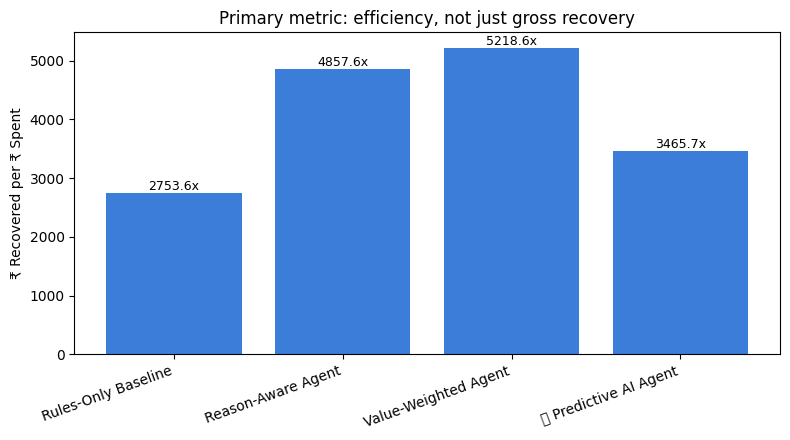

In [32]:
# --- Optional: visualize the primary metric (₹ Recovered per ₹ Spent) ---
import matplotlib.pyplot as plt

plot_df = benchmark_table.copy()
plot_df["_roi_numeric"] = pd.to_numeric(plot_df["₹ Recovered / ₹ Spent"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(plot_df["Strategy"], plot_df["_roi_numeric"], color="#3b7dd8")
ax.set_ylabel("₹ Recovered per ₹ Spent")
ax.set_title("Primary metric: efficiency, not just gross recovery")
ax.set_xticklabels(plot_df["Strategy"], rotation=20, ha="right")
for bar, val in zip(bars, plot_df["_roi_numeric"]):
    if pd.notna(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.1f}x",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


In [33]:
import numpy as np
import pandas as pd

events_ex = pd.read_csv(f"{WORKDIR}/recovery_events.csv")
pa_ex = pd.read_csv(f"{WORKDIR}/payment_attempts.csv", parse_dates=["timestamp"])

UNRESOLVED_STATES = ["FAILED", "EXPIRED"]
unresolved = events_ex[events_ex["state"].isin(UNRESOLVED_STATES)].copy()

# Need transaction-level amount + bank/gateway/payment_method + hour, none of which
# live on recovery_events.csv -- pull them from payment_attempts.
pa_ex["hour_of_day"] = pa_ex["timestamp"].dt.hour

def hour_bucket(h):
    edges = [0, 3, 6, 9, 12, 15, 18, 21, 24]
    labels = ["12–3AM", "3–6AM", "6–9AM", "9AM–12PM", "12–3PM", "3–6PM", "6–9PM", "9PM–12AM"]
    for lo, hi, lab in zip(edges[:-1], edges[1:], labels):
        if lo <= h < hi:
            return lab
    return "unknown"

pa_ex["time_window"] = pa_ex["hour_of_day"].apply(hour_bucket)

# Drop payment_method from unresolved if it exists, to prevent _x/_y suffixes
if 'payment_method' in unresolved.columns:
    unresolved = unresolved.drop(columns=['payment_method'])

unresolved = unresolved.merge(
    pa_ex[["transaction_id", "amount", "bank", "gateway", "payment_method", "time_window"]],
    on="transaction_id", how="left",
)

# recovery_context is already on recovery_events.csv (confidence-gated prediction, or UNKNOWN).
GROUP_COLS = ["recovery_context", "bank", "gateway", "time_window"]

clusters = (
    unresolved.groupby(GROUP_COLS, dropna=False)
    .agg(
        unresolved_count=("transaction_id", "nunique"),
        unresolved_amount=("amount", "sum"),
        dominant_payment_method=("payment_method", lambda s: s.mode().iat[0] if len(s.mode()) else "n/a"),
        dominant_state=("state", lambda s: s.mode().iat[0] if len(s.mode()) else "n/a"),
    )
    .reset_index()
    .sort_values("unresolved_amount", ascending=False)
)

clusters.to_csv(f"{WORKDIR}/stage5_exception_clusters.csv", index=False)

print(f"Top unresolved patterns (of {unresolved['transaction_id'].nunique():,} unresolved transactions, "
      f"₹{unresolved['amount'].sum():,.2f} unresolved value)\n")

for _, r in clusters.head(10).iterrows():
    print(
        f"- {int(r['unresolved_count'])} unresolved {r['recovery_context']} failures "
        f"({r['dominant_state']}) on {r['gateway']} / {r['bank']} bank, "
        f"{r['time_window']}, mostly via {r['dominant_payment_method']} "
        f"— ₹{r['unresolved_amount']:,.2f} at stake"
    )

# ---------------------------------------------------------------------
# Optional bonus: a genuine unsupervised cluster (KMeans) over encoded
# categorical features + amount, for teams that want "real" clustering
# on top of the rule-based groupby above (which is what the judge-facing
# sentence generator above actually uses).
# ---------------------------------------------------------------------
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

cluster_feats = unresolved[["recovery_context", "bank", "gateway", "payment_method", "time_window"]].fillna("NA")
ohe_ex = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_ex = ohe_ex.fit_transform(cluster_feats)

amt_scaled = StandardScaler().fit_transform(unresolved[["amount"]].fillna(0))
X_cluster = np.hstack([X_cat_ex, amt_scaled])

k = min(8, max(2, unresolved["transaction_id"].nunique() // 200))  # heuristic, tune as needed
km = KMeans(n_clusters=k, n_init=10, random_state=42)
unresolved["kmeans_cluster"] = km.fit_predict(X_cluster)

kmeans_summary = (
    unresolved.groupby("kmeans_cluster")
    .agg(count=("transaction_id", "nunique"), amount=("amount", "sum"))
    .sort_values("amount", ascending=False)
)
print("\nKMeans cluster sizes (bonus, unsupervised sanity check):")
print(kmeans_summary)

Top unresolved patterns (of 13,122 unresolved transactions, ₹18,323,146.71 unresolved value)

- 47 unresolved ERR_EXPIRED_CARD failures (FAILED) on Razorpay_G2 / ICICI bank, 6–9PM, mostly via NetBanking — ₹108,783.79 at stake
- 51 unresolved ERR_INSUFFICIENT_FUNDS failures (FAILED) on Razorpay_G2 / Axis bank, 12–3PM, mostly via Card — ₹94,735.58 at stake
- 55 unresolved ERR_INSUFFICIENT_FUNDS failures (FAILED) on Razorpay_G1 / Kotak bank, 6–9PM, mostly via UPI — ₹88,632.48 at stake
- 30 unresolved ERR_EXPIRED_CARD failures (FAILED) on Razorpay_G1 / Kotak bank, 9AM–12PM, mostly via Subscription — ₹88,455.40 at stake
- 39 unresolved ERR_INSUFFICIENT_FUNDS failures (FAILED) on Razorpay_G1 / Kotak bank, 12–3AM, mostly via Card — ₹85,498.69 at stake
- 48 unresolved ERR_INSUFFICIENT_FUNDS failures (FAILED) on Razorpay_G3 / Kotak bank, 6–9AM, mostly via UPI — ₹81,624.86 at stake
- 56 unresolved ERR_INSUFFICIENT_FUNDS failures (FAILED) on Razorpay_G1 / Axis bank, 12–3PM, mostly via NetBanking 

Batch 1 (fit recalibration): 92,926 attempts, 2026-08-01 00:00:16 -> 2026-08-22 00:13:45
Batch 2 (held-out eval)    : 39,826 attempts, 2026-08-22 00:15:12 -> 2026-08-30 23:59:31

                Stage  Brier Score  Log Loss  Δ Brier  Δ Log Loss
Before recalibration       0.1963    0.5732      NaN         NaN
 After recalibration       0.1964    0.5735   0.0001      0.0004


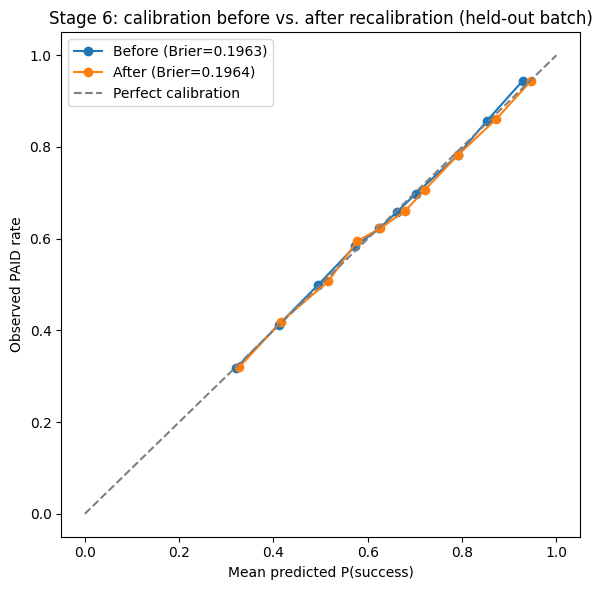

In [34]:
# =====================================================================
# Stage 6 — Feedback loop: controlled before/after recalibration
# Prediction -> Actual observed outcome -> Prediction error -> Recalibrate
# Offline, time-split, no online training.
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

events_fb = pd.read_csv(f"{WORKDIR}/recovery_events.csv", parse_dates=["timestamp"])

# Rows carrying a real (predicted_probability, actual_outcome) pair -- these three states
# are the outcome-event for a dispatched attempt, so predicted_probability and actual_outcome
# are both populated and non-pending here.
REALIZED_STATES = ["RECOVERED", "FAILED", "FAILED_RETRYABLE"]
realized = events_fb[events_fb["state"].isin(REALIZED_STATES)].copy()
realized = realized.dropna(subset=["predicted_probability"])
realized["y"] = (realized["actual_outcome"] == "PAID").astype(int)

# Time-ordered split: fit recalibration only on the past, evaluate only on the future.
realized = realized.sort_values("timestamp").reset_index(drop=True)
split_idx = int(len(realized) * 0.70)
batch1 = realized.iloc[:split_idx]   # used to FIT the recalibration mapping
batch2 = realized.iloc[split_idx:]   # held out -- before/after is scored here only

print(f"Batch 1 (fit recalibration): {len(batch1):,} attempts, {batch1['timestamp'].min()} -> {batch1['timestamp'].max()}")
print(f"Batch 2 (held-out eval)    : {len(batch2):,} attempts, {batch2['timestamp'].min()} -> {batch2['timestamp'].max()}")

# ---------- BEFORE: raw XGBoost recovery-probability on the held-out batch ----------
raw_p = batch2["predicted_probability"].clip(1e-4, 1 - 1e-4)
brier_before = brier_score_loss(batch2["y"], raw_p)
logloss_before = log_loss(batch2["y"], raw_p)

# ---------- Fit recalibration on batch 1 only (isotonic regression) ----------
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(batch1["predicted_probability"], batch1["y"])

# ---------- AFTER: apply batch-1-fit recalibration to batch 2 ----------
recal_p = pd.Series(iso.predict(batch2["predicted_probability"]), index=batch2.index).clip(1e-4, 1 - 1e-4)
brier_after = brier_score_loss(batch2["y"], recal_p)
logloss_after = log_loss(batch2["y"], recal_p)

summary = pd.DataFrame([
    {"Stage": "Before recalibration", "Brier Score": round(brier_before, 4), "Log Loss": round(logloss_before, 4)},
    {"Stage": "After recalibration",  "Brier Score": round(brier_after, 4),  "Log Loss": round(logloss_after, 4)},
])
summary["Δ Brier"] = [np.nan, round(brier_after - brier_before, 4)]
summary["Δ Log Loss"] = [np.nan, round(logloss_after - logloss_before, 4)]
print("\n", summary.to_string(index=False))

summary.to_csv(f"{WORKDIR}/stage6_recalibration_summary.csv", index=False)
batch2.assign(recalibrated_probability=recal_p).to_csv(f"{WORKDIR}/stage6_recalibration_eval.csv", index=False)

# ---------- Calibration curves, before vs after ----------
frac_before, mean_before = calibration_curve(batch2["y"], raw_p, n_bins=10, strategy="quantile")
frac_after, mean_after = calibration_curve(batch2["y"], recal_p, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_before, frac_before, marker="o", label=f"Before (Brier={brier_before:.4f})")
ax.plot(mean_after, frac_after, marker="o", label=f"After (Brier={brier_after:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted P(success)")
ax.set_ylabel("Observed PAID rate")
ax.set_title("Stage 6: calibration before vs. after recalibration (held-out batch)")
ax.legend()
plt.tight_layout()
plt.show()